# Chapter 5 : Inference-time scaling


- This chapter covers
  - Scoring LLM answers with a simple rule-based scorer
  - Computing an LLM’s confidence in its answers
  - Coding a self-refinement loop where the LLM iteratively improves its answers


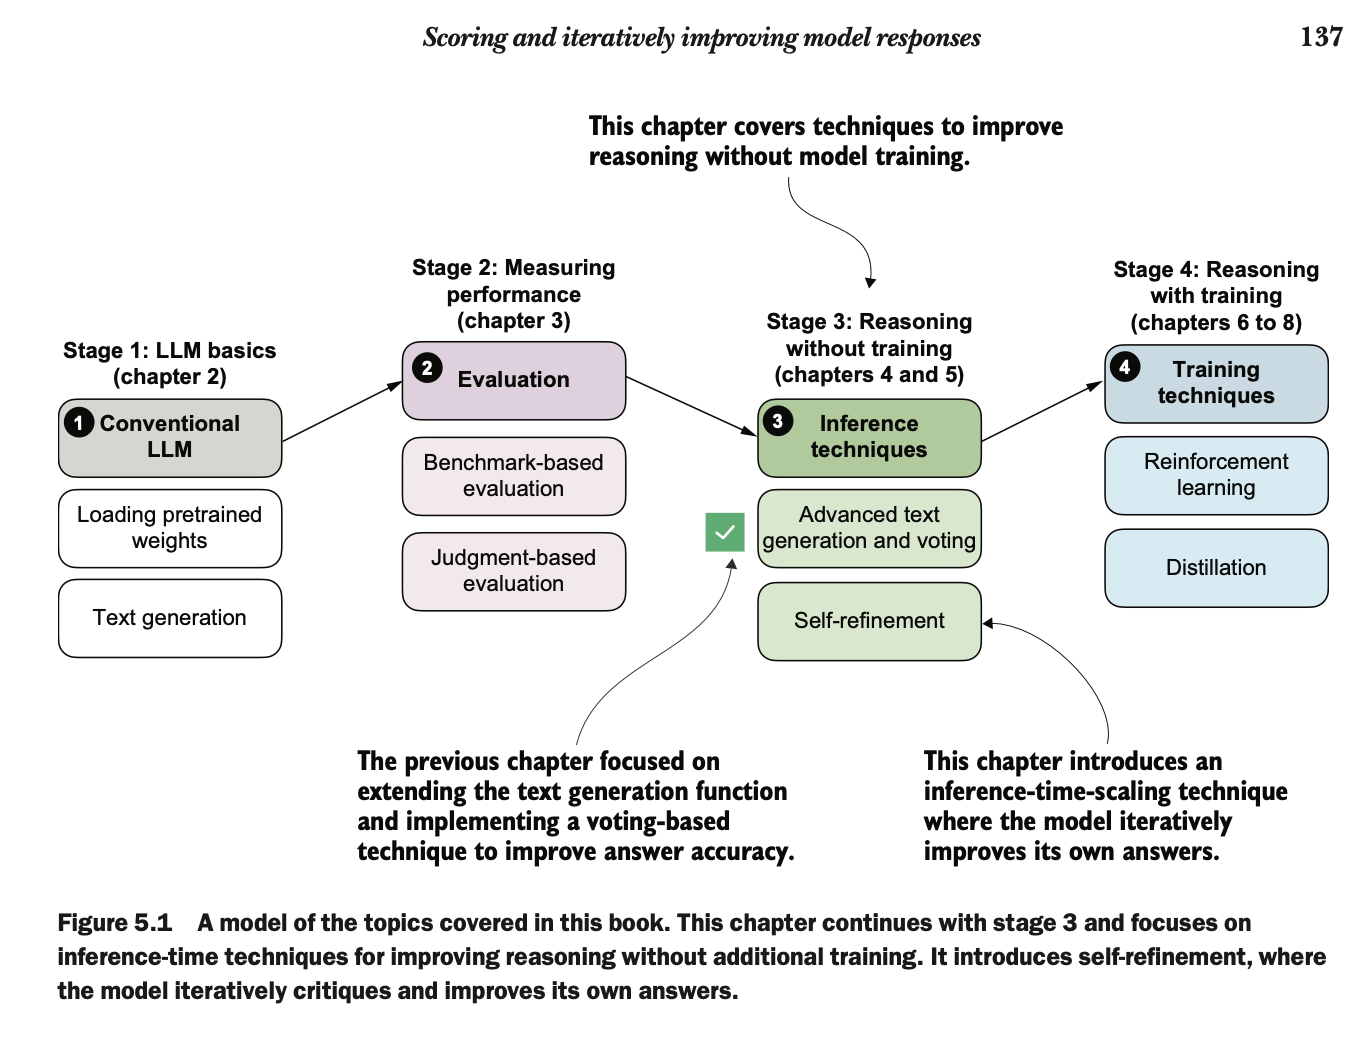


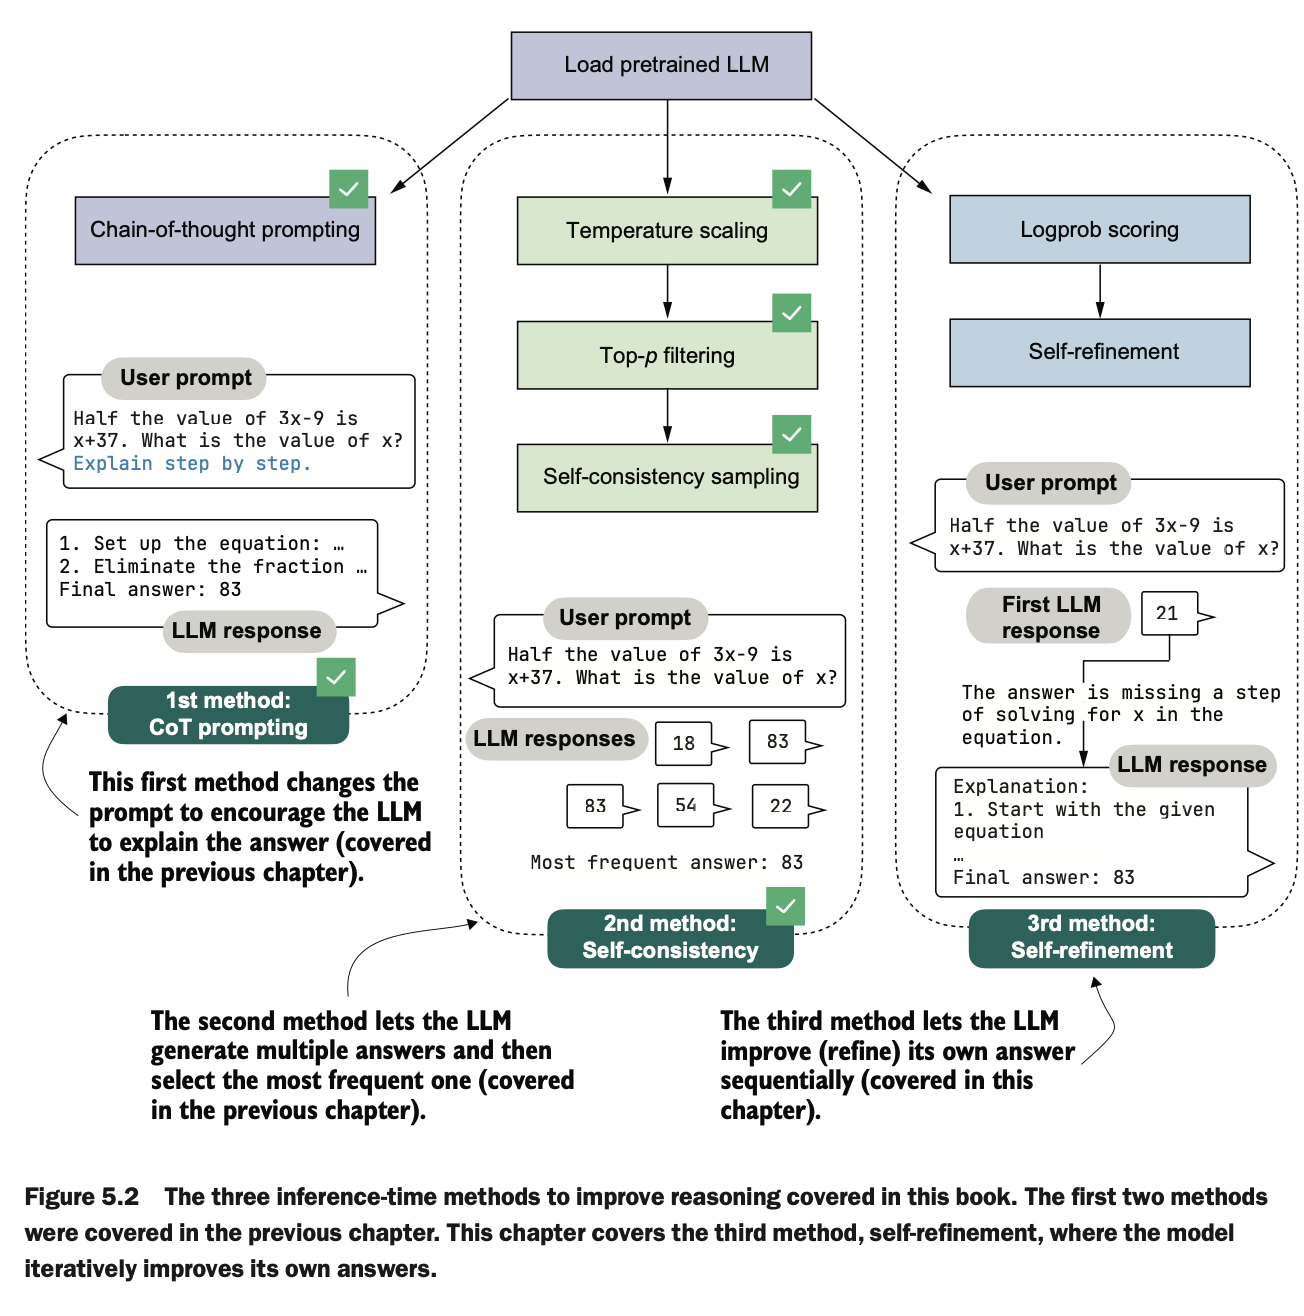


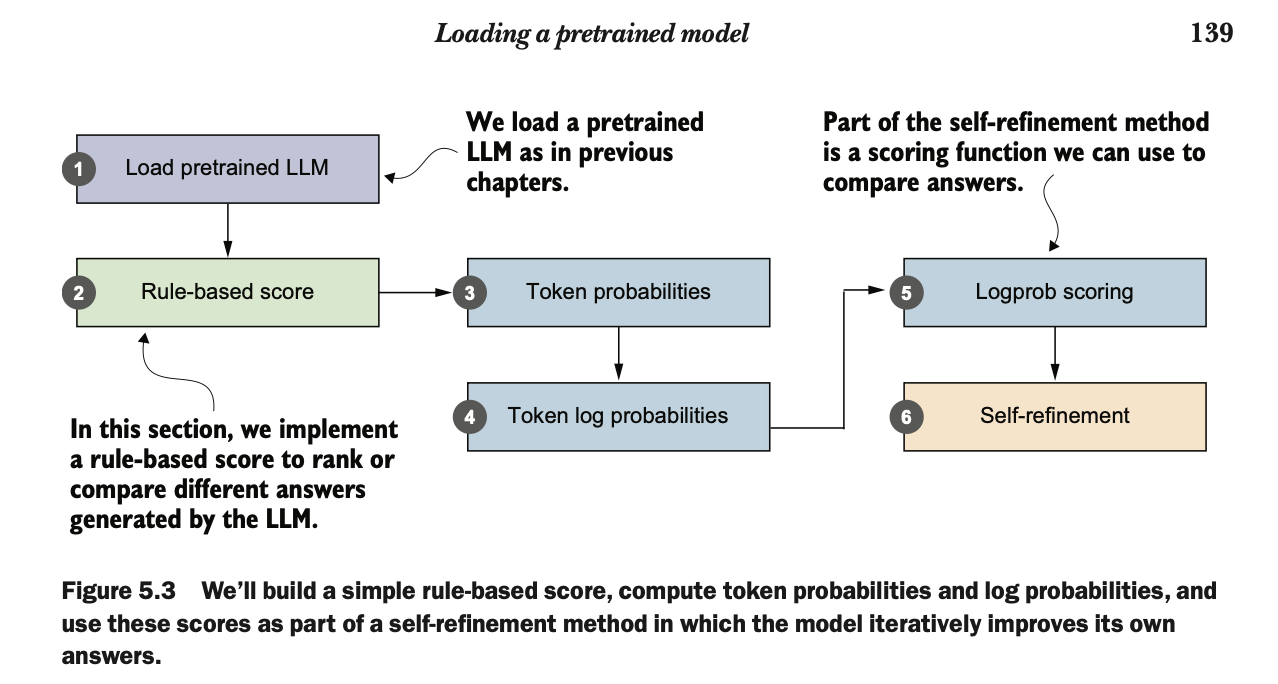


# 5.2 Loading a pretrained model


In [1]:
# Listing 5.1 Loading the tokenizer and base model

import torch
from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import load_model_and_tokenizer

device = get_device()

model, tokenizer = load_model_and_tokenizer(
    which_model="base", device=device, use_compile=False
)

Using Apple Silicon GPU (MPS)
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


In [2]:
# Listing 5.2 Generating text with temperature scaling and top-p sampling

from reasoning_from_scratch.ch03 import render_prompt
from reasoning_from_scratch.ch04 import (
    generate_text_stream_concat_flex,
    generate_text_top_p_stream_cache,
)

raw_prompt = "Half the value of $3x-9$ is $x+37$. " "What is the value of $x$?"
prompt = render_prompt(raw_prompt)
prompt_cot = prompt + "\n\nExplain step by step."

torch.manual_seed(0)
response_1 = generate_text_stream_concat_flex(
    model,
    tokenizer,
    prompt_cot,
    device,
    max_new_tokens=2048,
    verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9,
)

 ### Step 1: Understand the problem

The problem states that half the value of \(3x - 9\) is equal to \(x + 37\). We need to find the value of \(x\).

### Step 2: Translate the problem into an equation

Let's translate the given statement into an equation. Half of \(3x - 9\) is equal to \(x + 37\).

\[
\frac{1}{2}(3x - 9) = x + 37
\]

### Step 3: Solve the equation

To solve for \(x\), we'll first eliminate the fraction by multiplying both sides of the equation by 2:

\[
2 \times \frac{1}{2}(3x - 9) = 2 \times (x + 37)
\]

This simplifies to:

\[
3x - 9 = 2x + 74
\]

### Step 4: Isolate the variable \(x\)

Now, we'll isolate \(x\) by subtracting \(2x\) from both sides of the equation:

\[
3x - 2x - 9 = 74
\]

Simplifying this, we get:

\[
x - 9 = 74
\]

### Step 5: Solve for \(x\)

Next, we'll add 9 to both sides to solve for \(x\):

\[
x - 9 + 9 = 74 + 9
\]

This simplifies to:

\[
x = 83
\]

### Step 6: Verify the solution

To ensure our solution is correct, we'll substitute \(x = 83

In [3]:
# Because we are using temperature scaling and top-p sampling, changing the random
# seed produces a different response:

torch.manual_seed(3)
response_2 = generate_text_stream_concat_flex(
    model,
    tokenizer,
    prompt_cot,
    device,
    max_new_tokens=2048,
    verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9,
)

 We start with the equation:

\[
\frac{1}{2} \times (3x - 9) = x + 37
\]

Step 1: Multiply both sides of the equation by 2 to eliminate the fraction:

\[
2 \times \frac{1}{2} \times (3x - 9) = 2 \times (x + 37)
\]

Simplifying both sides:

\[
3x - 9 = 2x + 74
\]

Step 2: Subtract \(2x\) from both sides to get all the \(x\)-terms on one side:

\[
3x - 2x - 9 = 74
\]

Simplifying:

\[
x - 9 = 74
\]

Step 3: Add 9 to both sides to isolate \(x\):

\[
x - 9 + 9 = 74 + 9
\]

Simplifying:

\[
x = 83
\]

Final Answer:

\[
\boxed{83}
\]

In [4]:
print("Response 1 characters:", len(response_1))
print("Response 1 tokens:", len(tokenizer.encode(response_1)))
print("\nResponse 2 characters:", len(response_2))
print("Response 2 tokens:", len(tokenizer.encode(response_2)))

Response 1 characters: 1419
Response 1 tokens: 534

Response 2 characters: 533
Response 2 tokens: 232


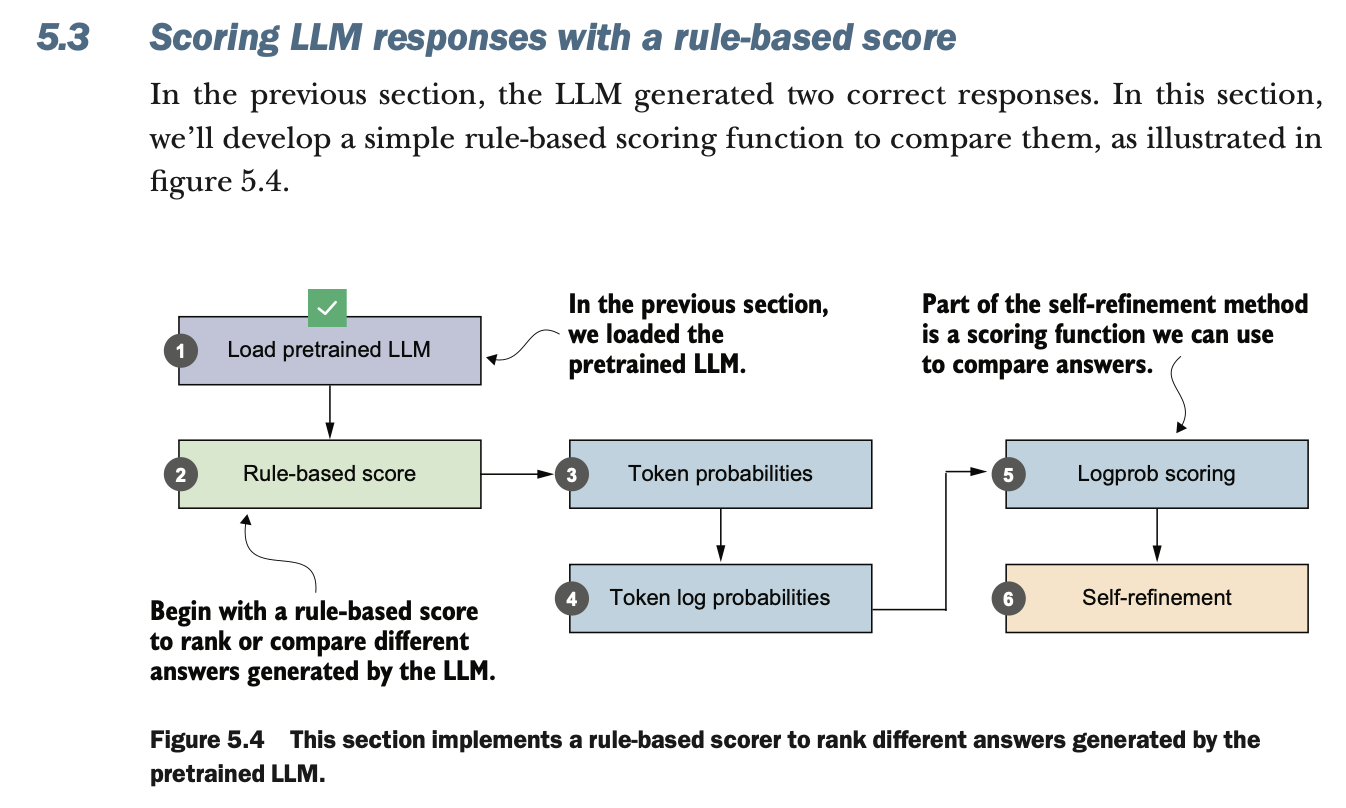


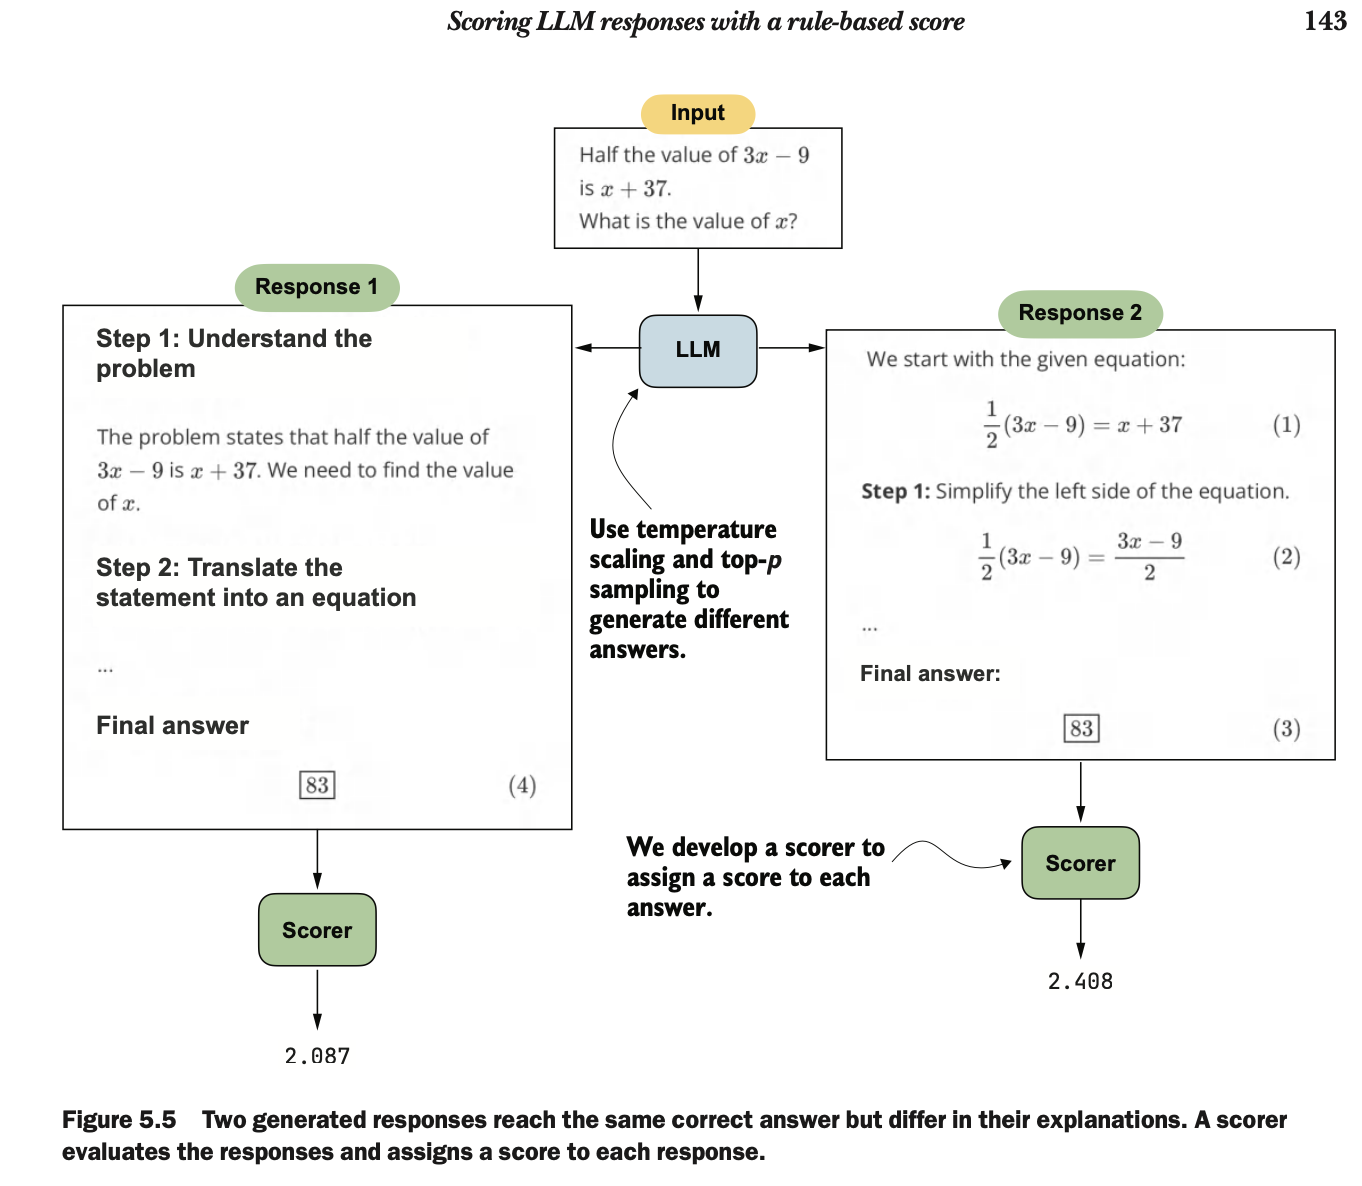


In [5]:
# Listing 5.3 A simple rule-based scorer

from reasoning_from_scratch.ch03 import extract_final_candidate
import math


def heuristic_score(
    answer,
    prompt=None,  # Placeholder that is ignored
    brevity_bonus=500.0,
    boxed_bonus=2.0,
    extract_bonus=1.0,
    fulltext_bonus=0.0,
):
    score = 0.0

    # Reward answers that have a final boxed value
    cand = extract_final_candidate(answer, fallback="none")
    if cand:
        score += boxed_bonus

    # Give weaker rewards if answer doesn't have a boxed value
    else:
        cand = extract_final_candidate(answer, fallback="number_only")
        if cand:
            score += extract_bonus
        else:
            cand = extract_final_candidate(answer, fallback="number_then_full")
            if cand:
                score += fulltext_bonus

    # Add a brevity reward that decays with text length
    score += 1.5 * math.exp(-len(answer) / brevity_bonus)
    return score

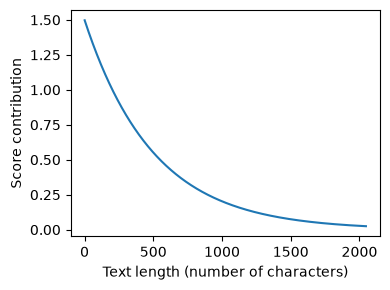

In [6]:
# Listing 5.4 Plotting the brevity penalty curve

import matplotlib.pyplot as plt


def plot_brevity_curve(brevity_bonus, max_len=2048):

    lengths = torch.arange(1, max_len)
    scores = 1.5 * torch.exp(-lengths / brevity_bonus)

    plt.figure(figsize=(4, 3))
    plt.plot(lengths, scores)
    plt.xlabel("Text length (number of characters)")
    plt.ylabel("Score contribution")
    plt.tight_layout()
    # plt.savefig("brevity_curve.pdf")
    plt.show()


plot_brevity_curve(500)

In [7]:
# We can now apply the heuristic scorer to the first (longer) response from section 5.2:

print(round(heuristic_score(response_1), 3))

# The resulting score is 2.088. Next, let’s try the second (shorter) response:
print(round(heuristic_score(response_2), 3))

2.088
2.517


# 5.4 Understanding token probability scores

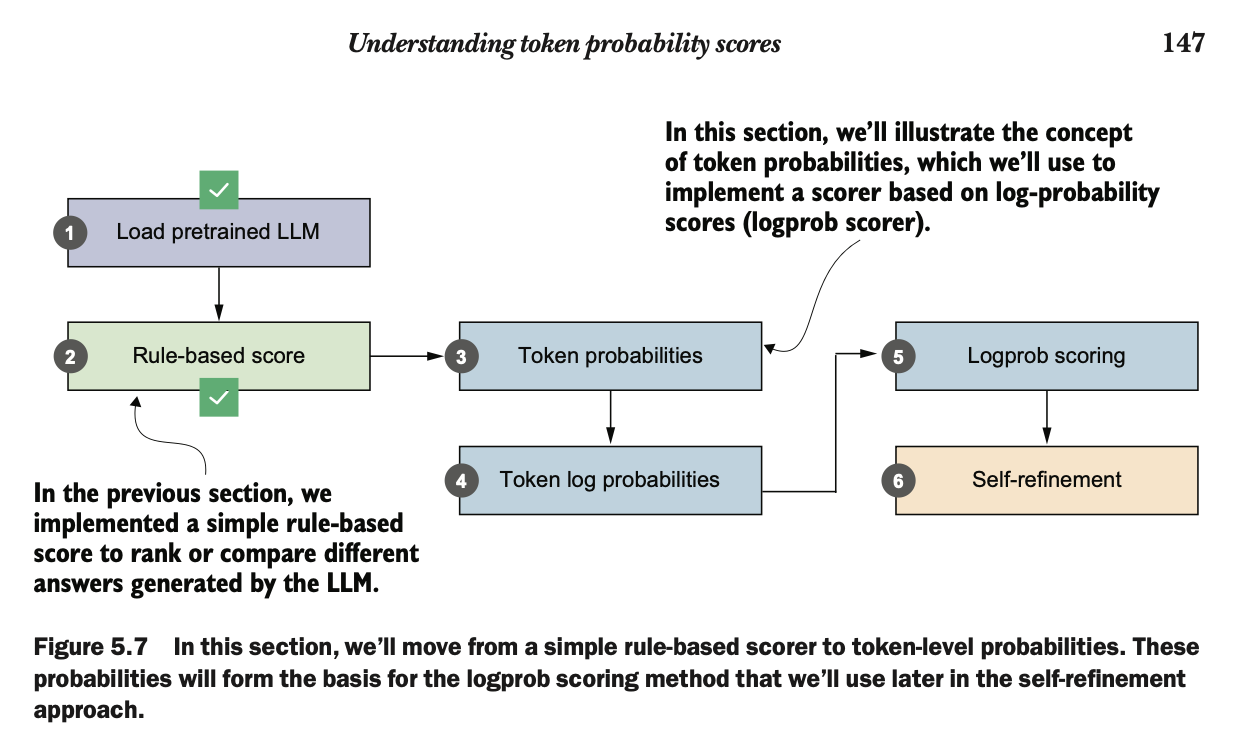
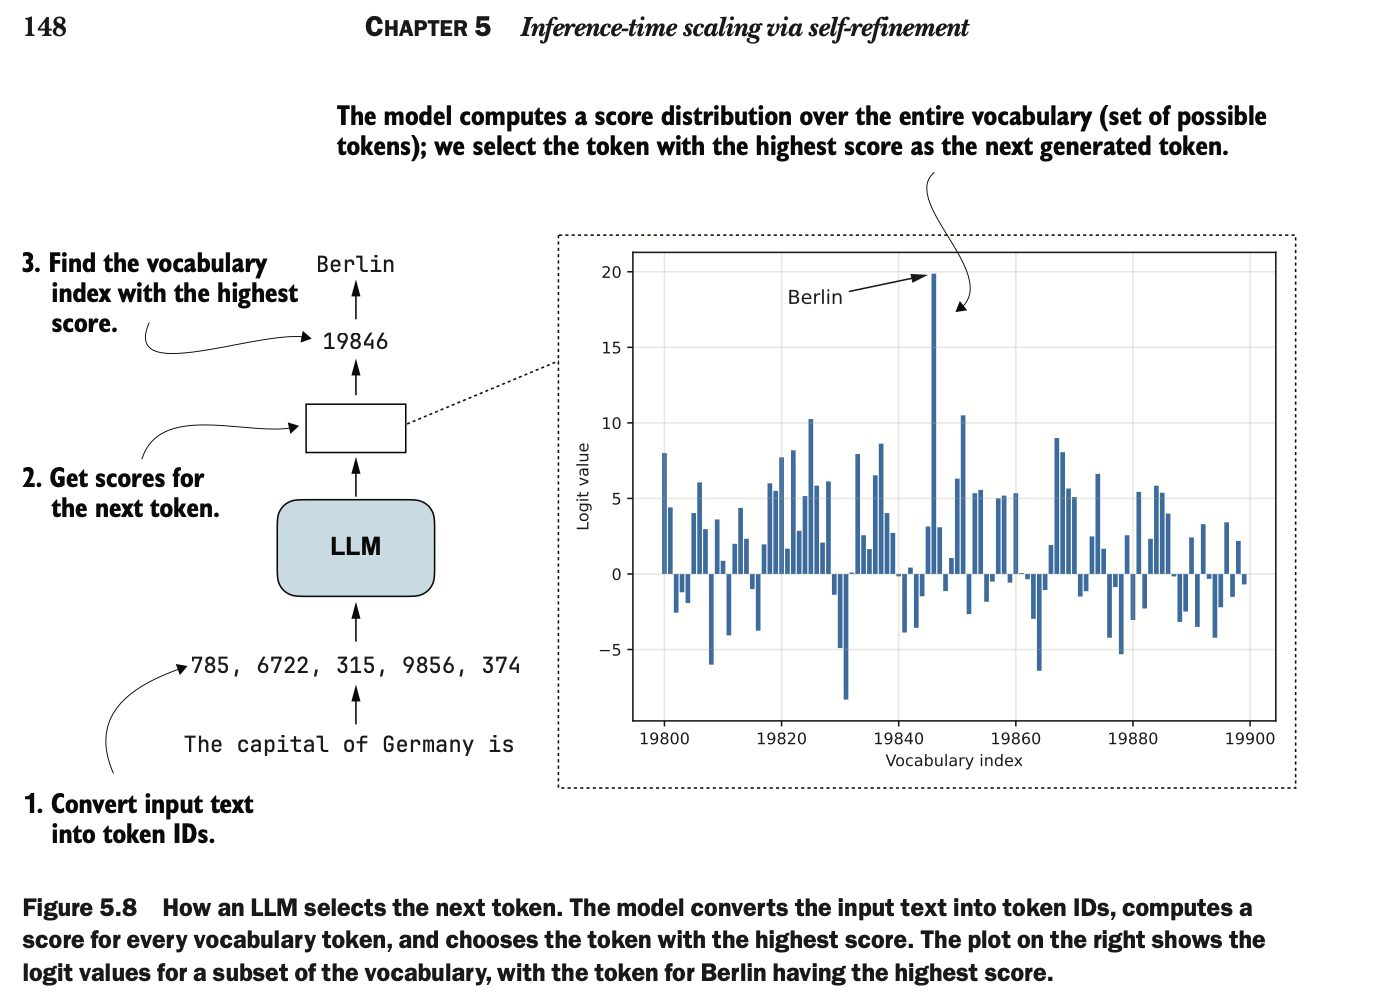
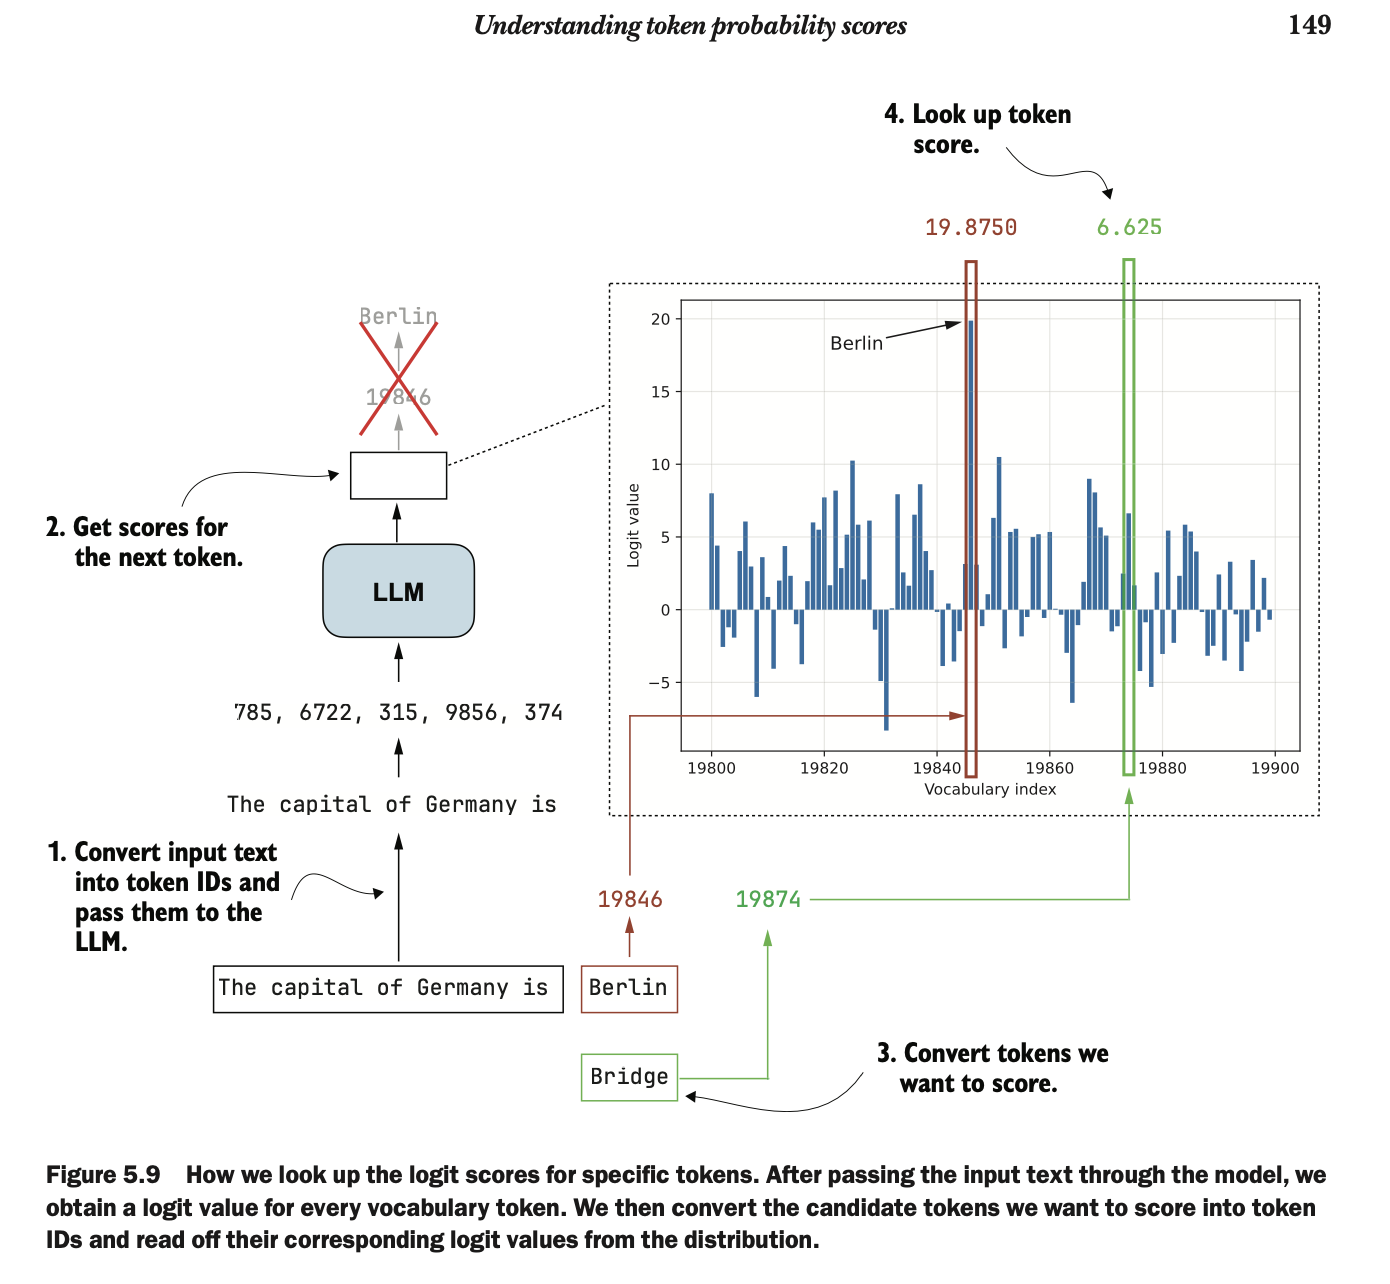
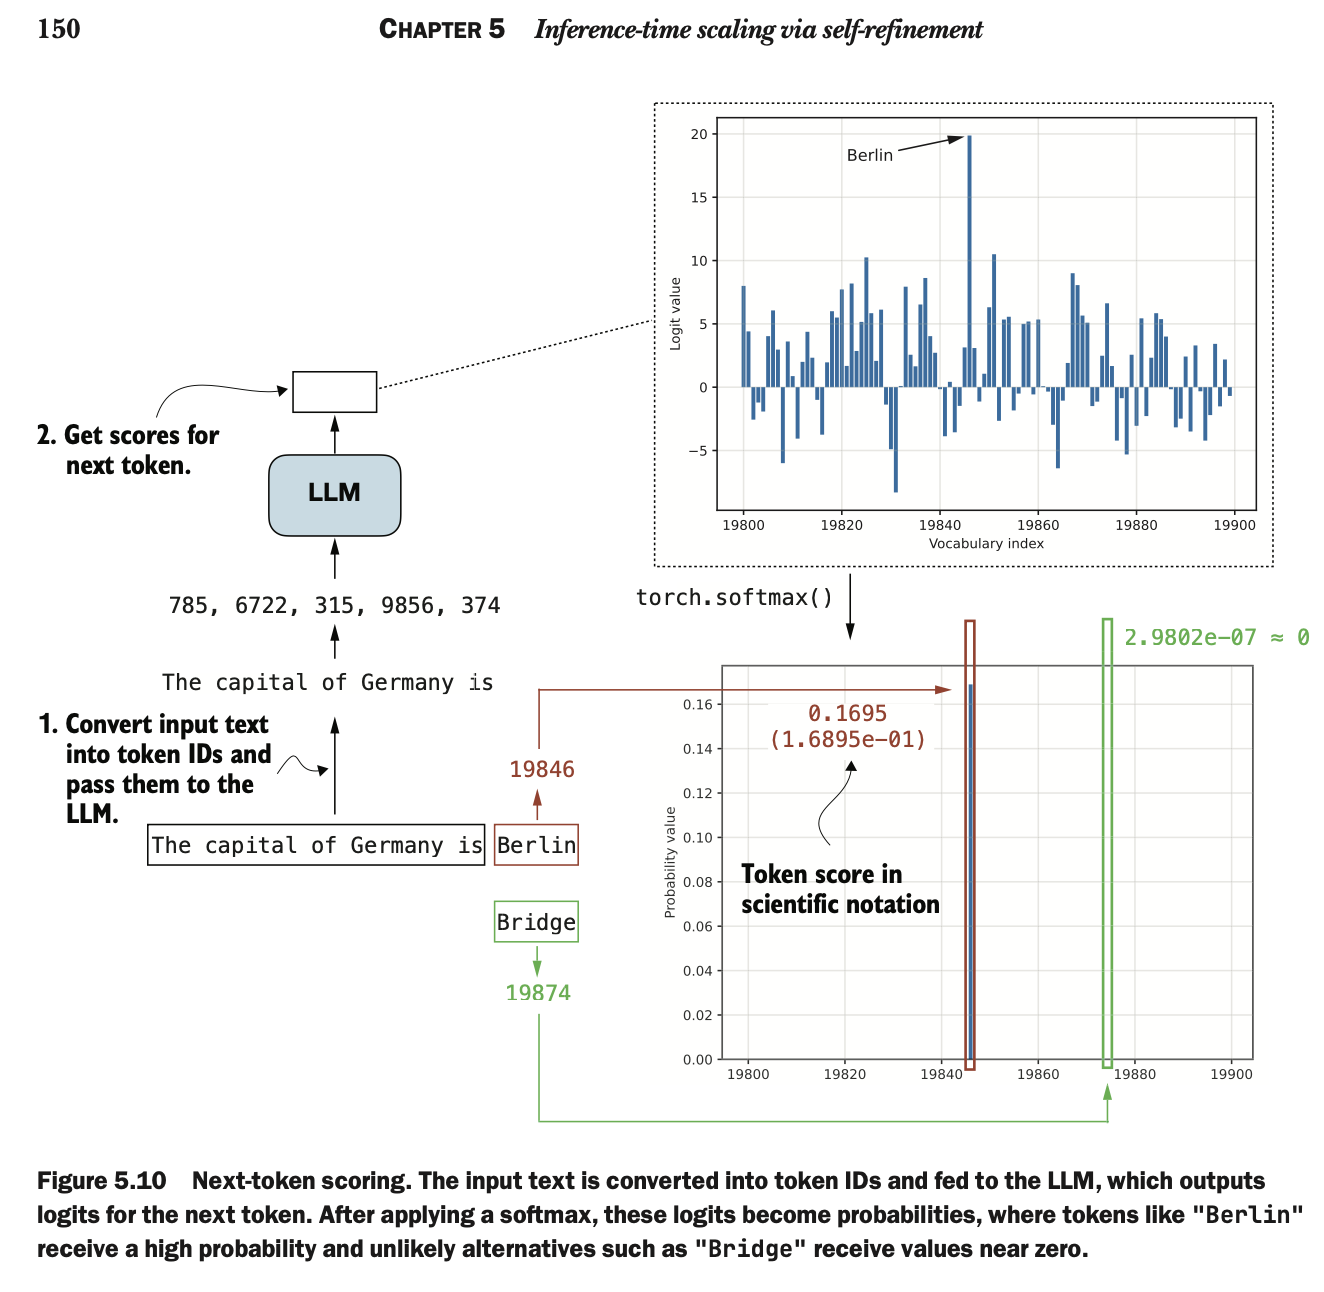
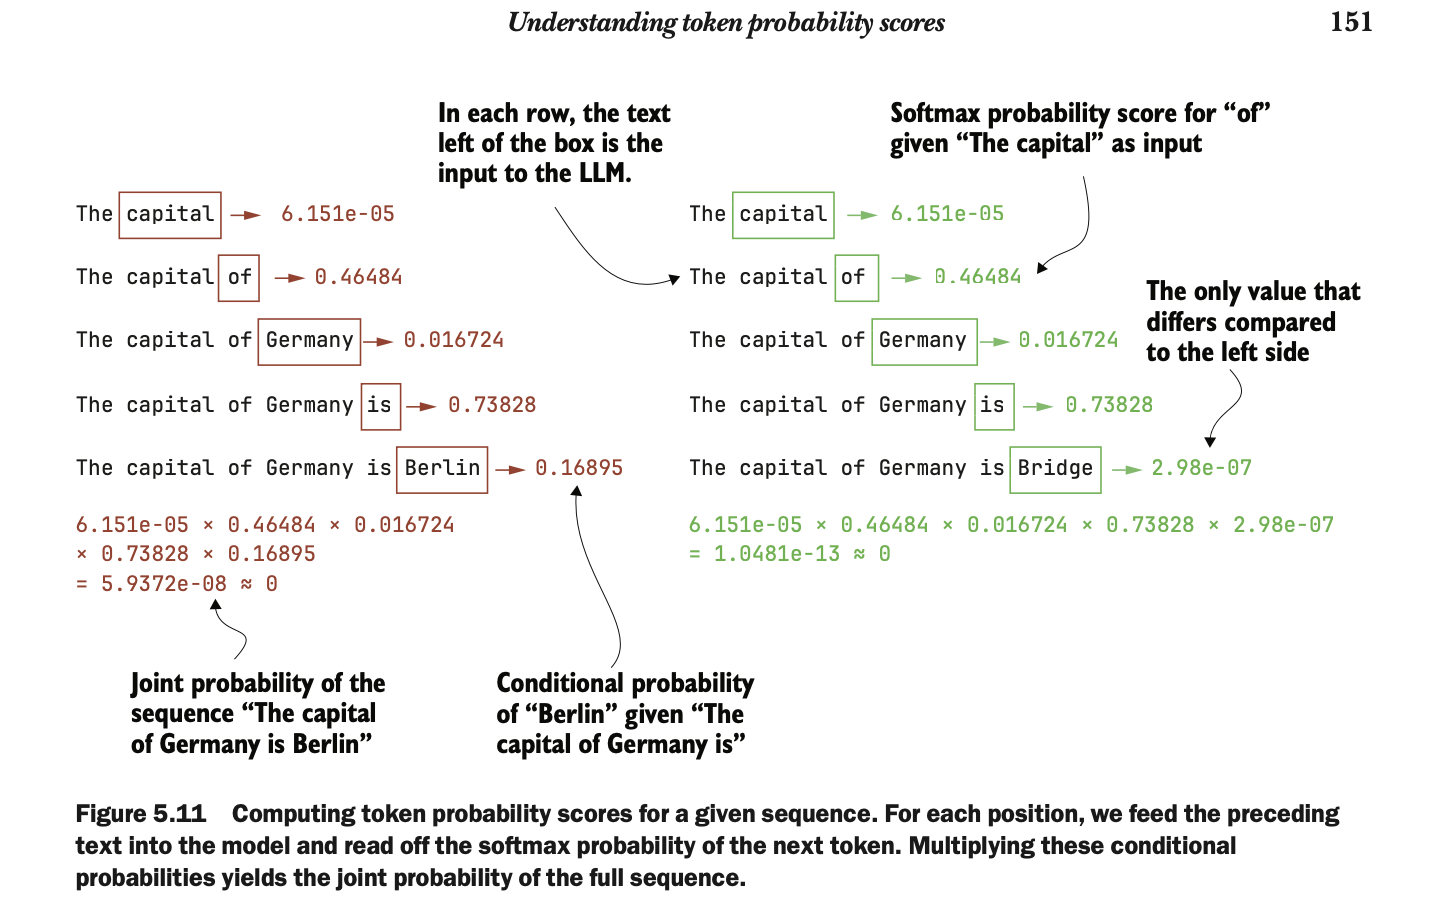


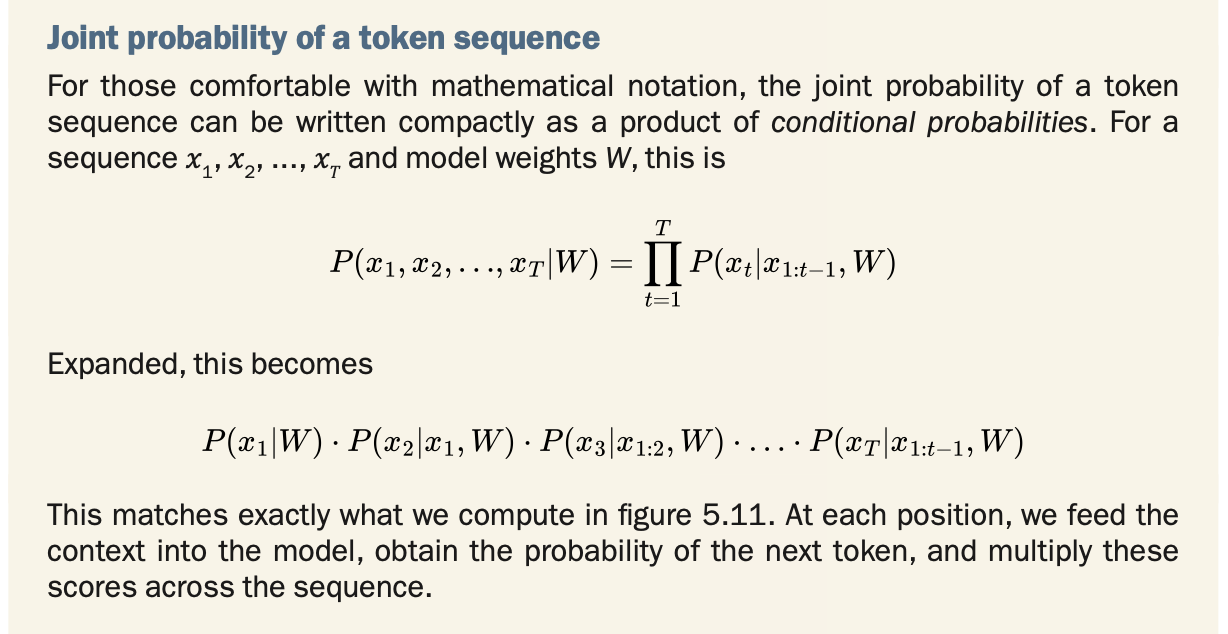


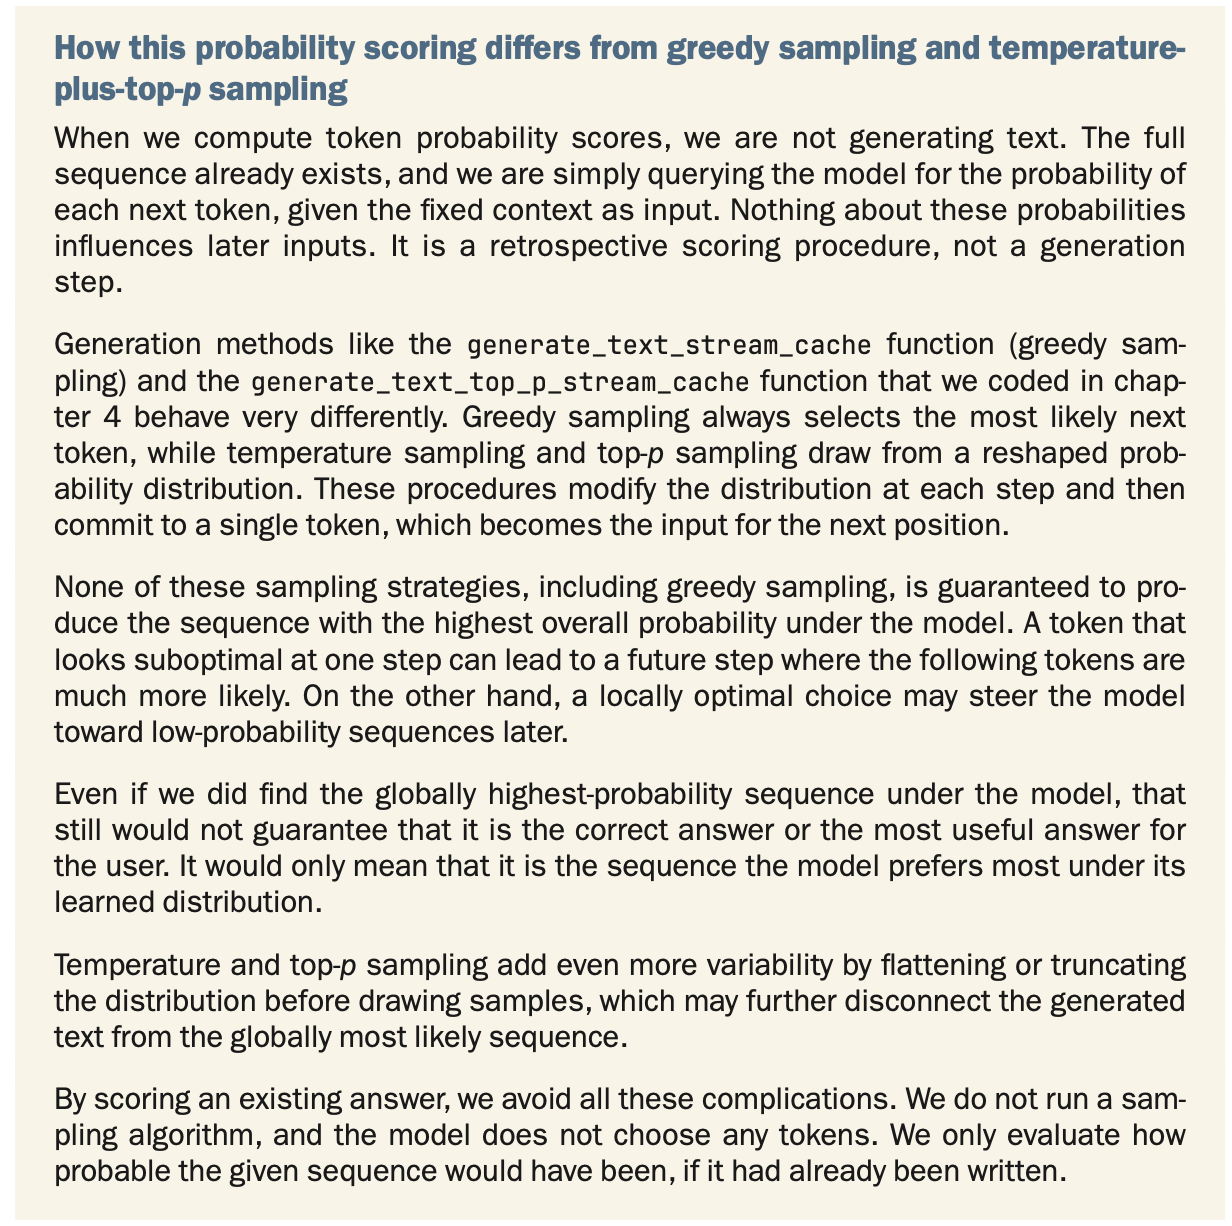


In [8]:
# Listing 5.5 Calculating next-token probabilities


@torch.inference_mode()
def calc_next_token_probas(model, tokenizer, prompt, device, show=True):

    token_ids = torch.tensor(tokenizer.encode(prompt), device=device)

    # Get logits and probabilities similar to text generation functions
    logits = model(token_ids.unsqueeze(0)).squeeze(0)
    all_probas = torch.softmax(logits, dim=-1)

    # Positions we score (here: all)
    t_idx = torch.arange(0, token_ids.shape[0] - 1, device=device)

    # Since we have the text, we know the true next tokens
    next_ids = token_ids[1:]

    # Get probabilities for each next token
    next_token_probas = all_probas[t_idx, next_ids]

    # Likelihood of the sequence is the product of the probability scores
    prod_next_token_probas = torch.prod(next_token_probas)

    if show:
        print("Next-token probabilities:", next_token_probas)
        print("Joint probability:", prod_next_token_probas)

    else:
        return next_token_probas, prod_next_token_probas

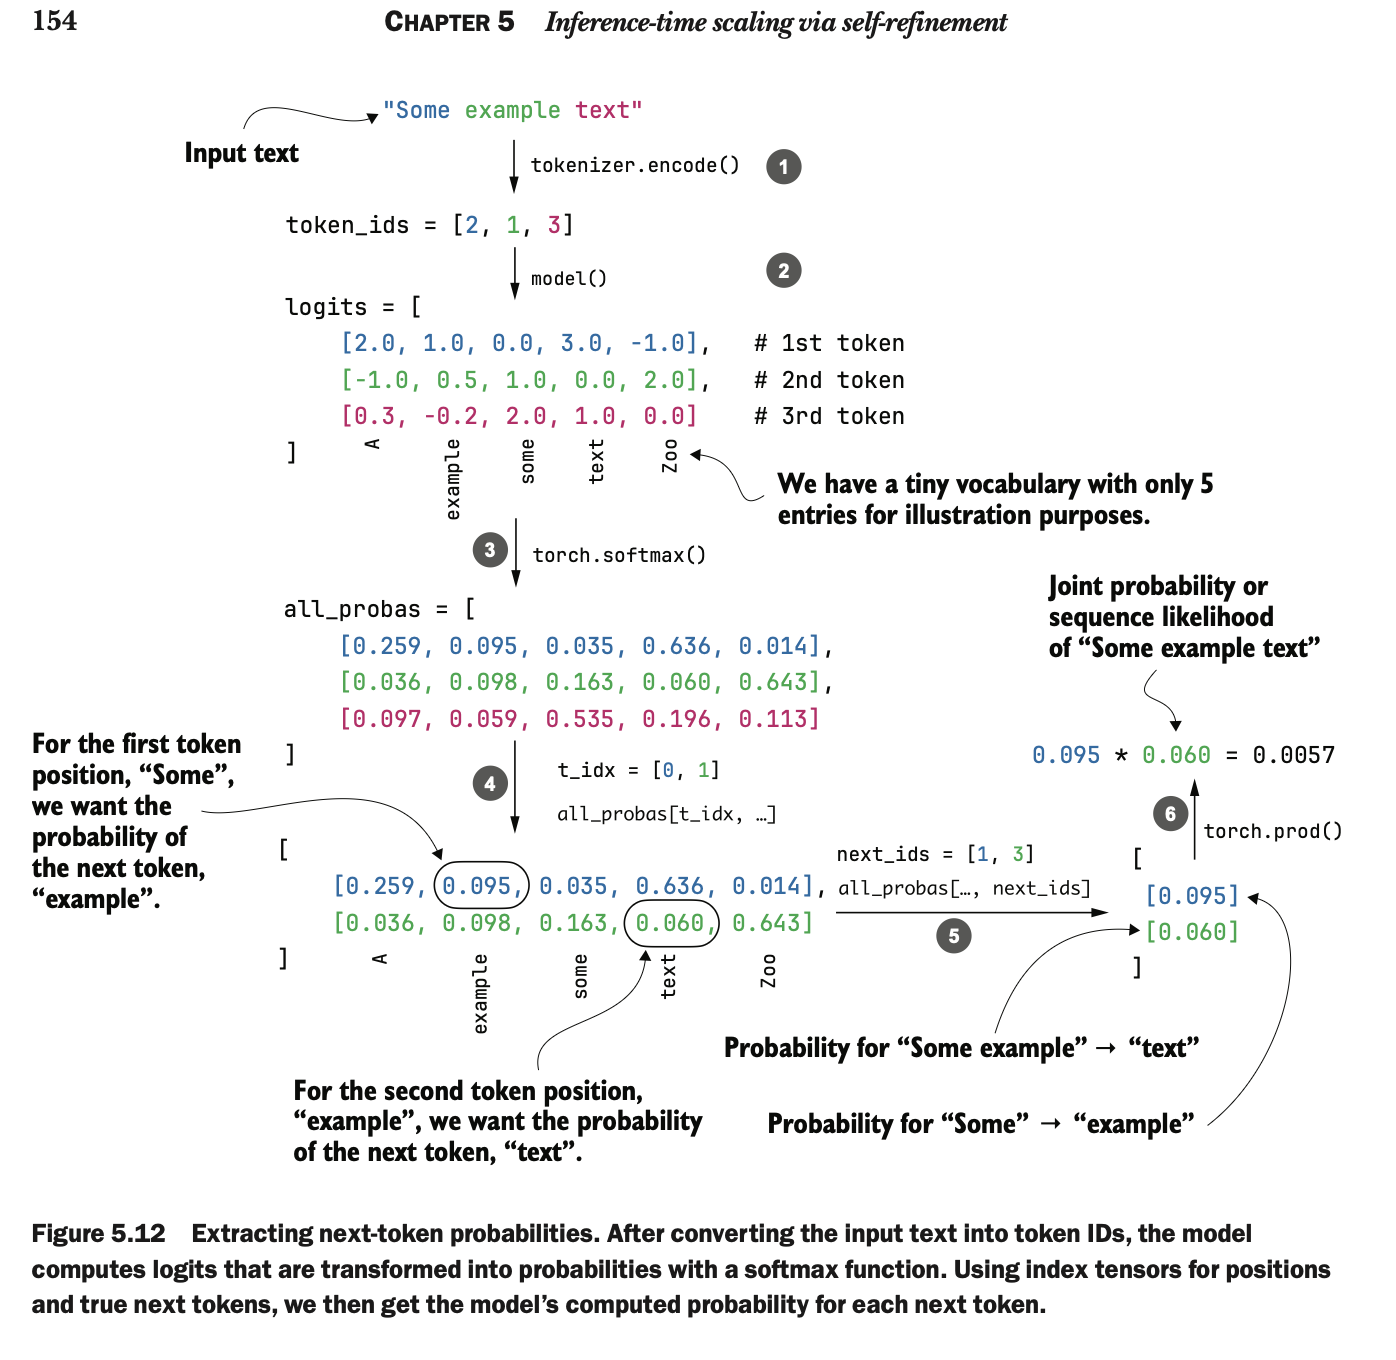


In [9]:
# Let’s see this function in action :
torch.set_printoptions(precision=4, sci_mode=True)
calc_next_token_probas(
    model, tokenizer, device=device, prompt="The capital of Germany is Berlin"
)

Next-token probabilities: tensor([5.7936e-05, 4.5117e-01, 1.6235e-02, 7.2656e-01, 1.6211e-01],
       device='mps:0', dtype=torch.bfloat16)
Joint probability: tensor(5.0059e-08, device='mps:0', dtype=torch.bfloat16)


In [10]:
calc_next_token_probas(
    model, tokenizer, device=device, prompt="The capital of Germany is Bridge"
)

Next-token probabilities: tensor([5.7936e-05, 4.5117e-01, 1.6235e-02, 7.2656e-01, 3.0361e-07],
       device='mps:0', dtype=torch.bfloat16)
Joint probability: tensor(9.3703e-14, device='mps:0', dtype=torch.bfloat16)


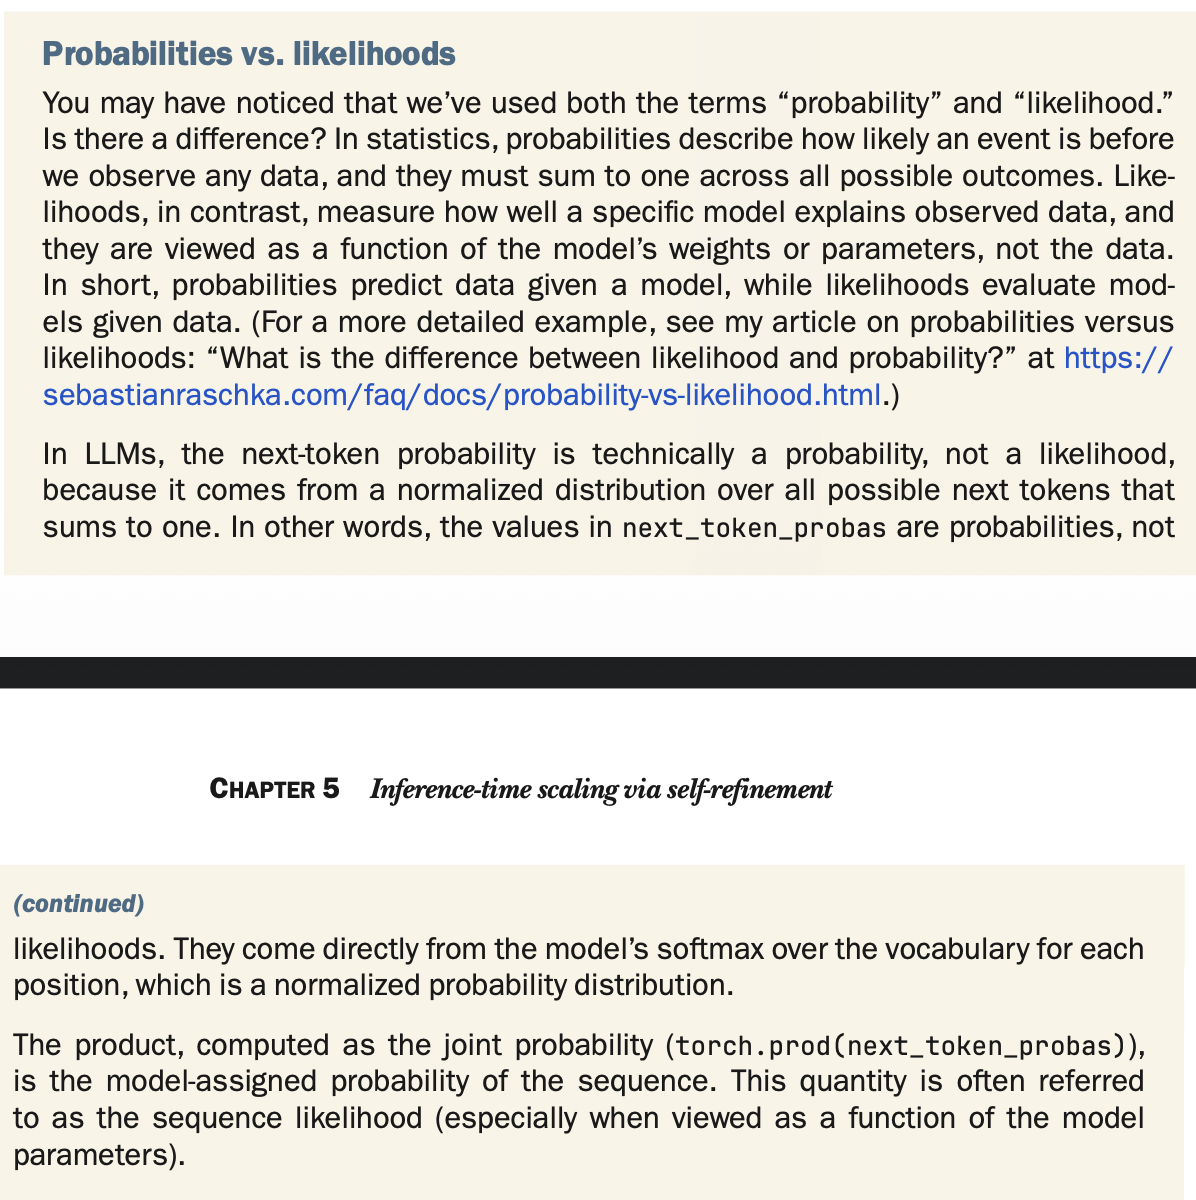


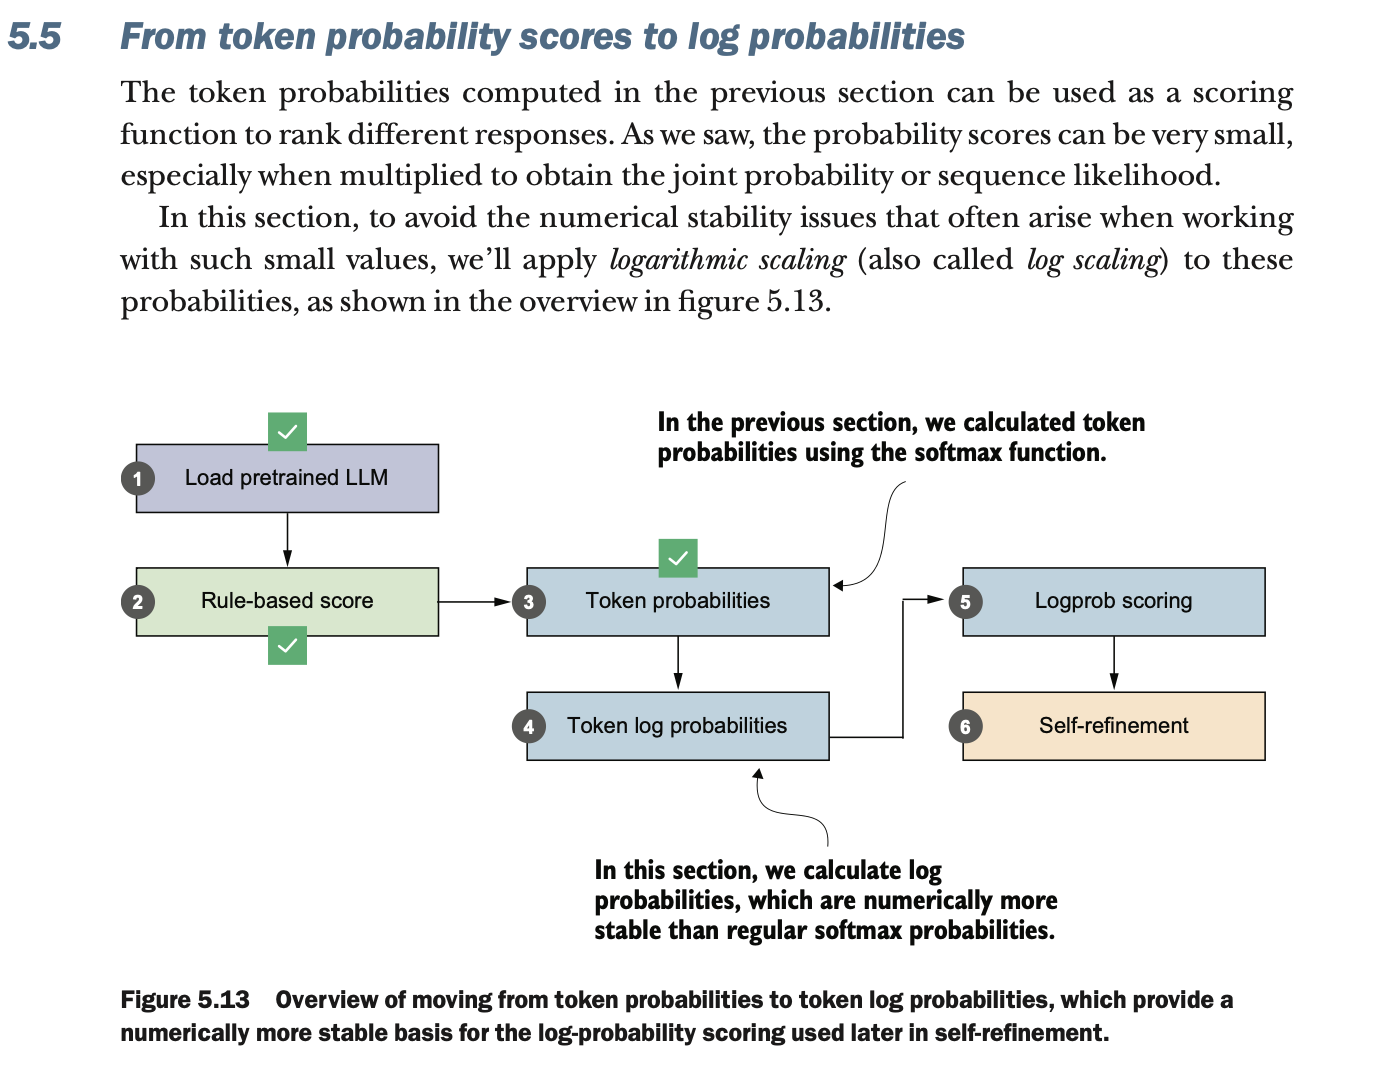


In [11]:
torch.set_printoptions(precision=4, sci_mode=False)
logits = torch.linspace(-2, 2, steps=7)
probas = torch.softmax(logits, dim=-1)
print(probas)

tensor([0.0090, 0.0175, 0.0341, 0.0665, 0.1295, 0.2522, 0.4912])


In [12]:
# We can turn them into log-probability scores via the torch.log function:

print(torch.log(probas))

tensor([-4.7109, -4.0442, -3.3776, -2.7109, -2.0442, -1.3776, -0.7109])


In [13]:
# Instead of chaining torch.log(torch.softmax(...)), PyTorch also has an optimized
# torch.log_softmax function that combines these two operations:

log_probas = torch.log_softmax(logits, dim=-1)
print(log_probas)

tensor([-4.7109, -4.0442, -3.3776, -2.7109, -2.0442, -1.3776, -0.7109])


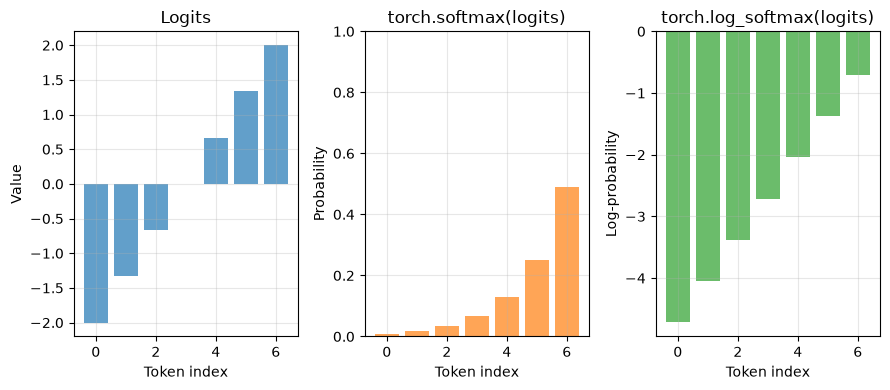

In [14]:
# Listing 5.6 Plotting logits, softmax probabilities, and log-softmax values

plt.figure(figsize=(9, 4))

# Logits
plt.subplot(1, 3, 1)
plt.bar(range(len(logits)), logits, color="C0", alpha=0.7)
plt.title("Logits")
plt.xlabel("Token index")
plt.ylabel("Value")
plt.grid(alpha=0.3)

# Softmax
plt.subplot(1, 3, 2)
plt.bar(range(len(probas)), probas, color="C1", alpha=0.7)
plt.title("torch.softmax(logits)")
plt.xlabel("Token index")
plt.ylabel("Probability")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

# Log-softmax
plt.subplot(1, 3, 3)
plt.bar(range(len(log_probas)), log_probas, color="C2", alpha=0.7)
plt.title("torch.log_softmax(logits)")
plt.xlabel("Token index")
plt.ylabel("Log-probability")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("logits_softmax_log_softmax.pdf")
plt.show()

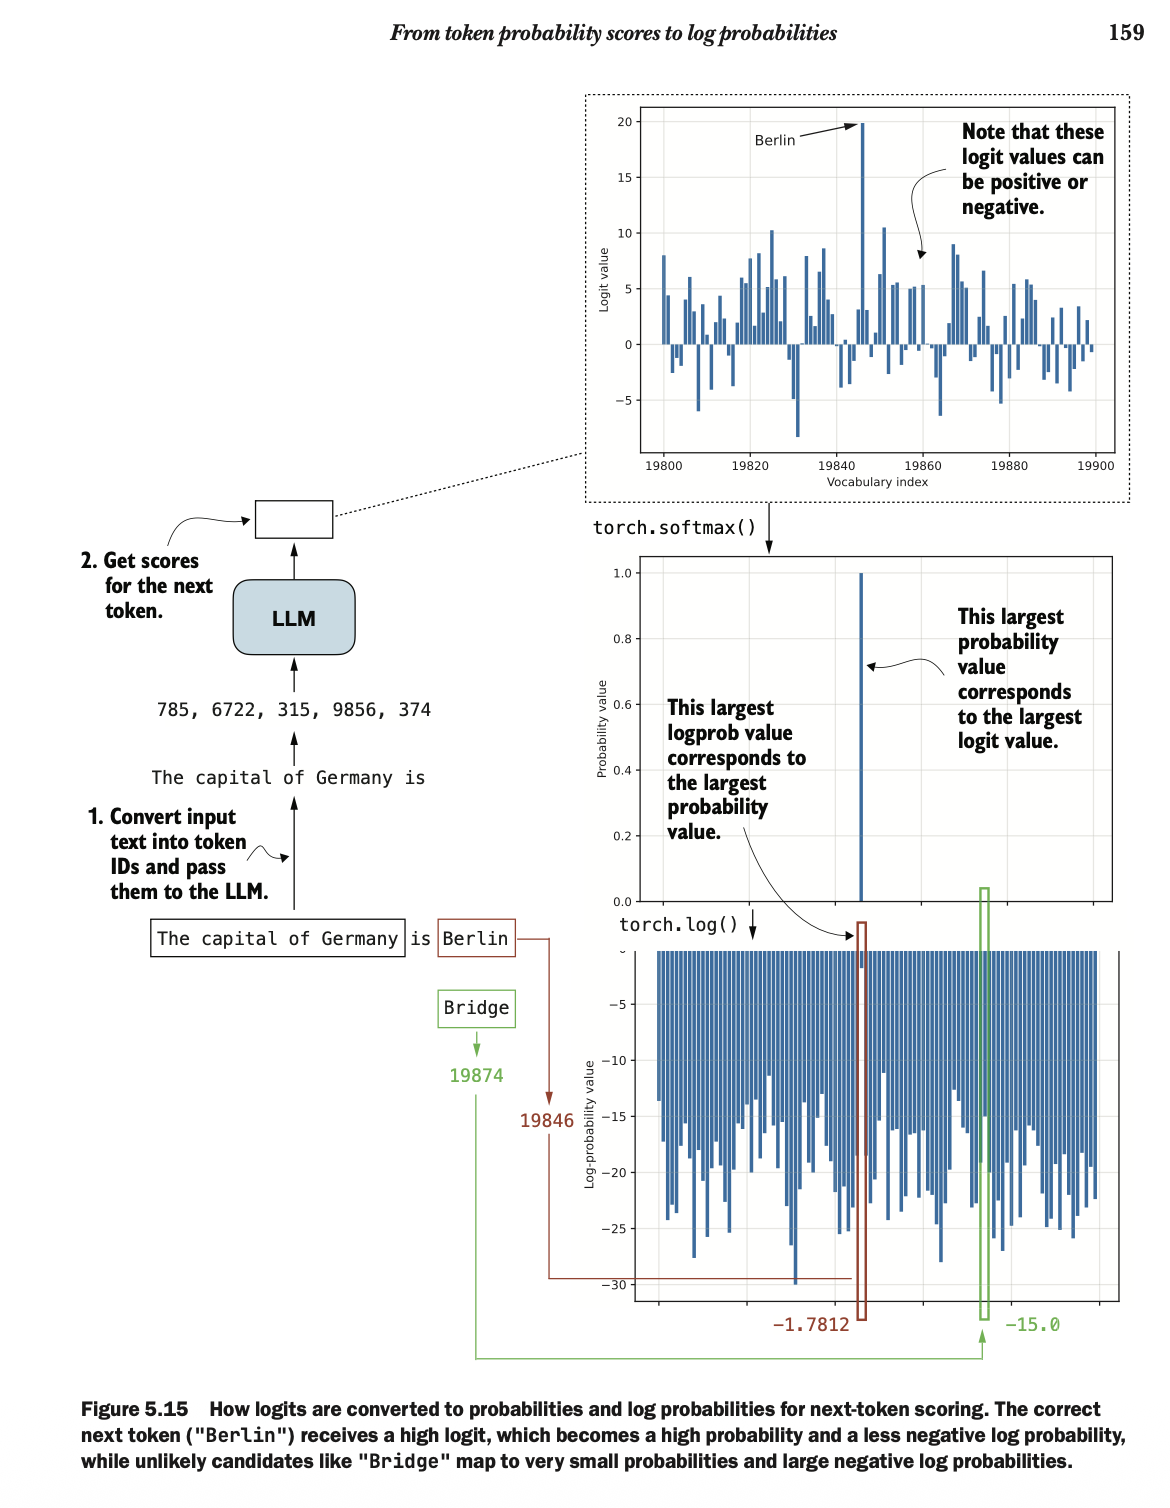


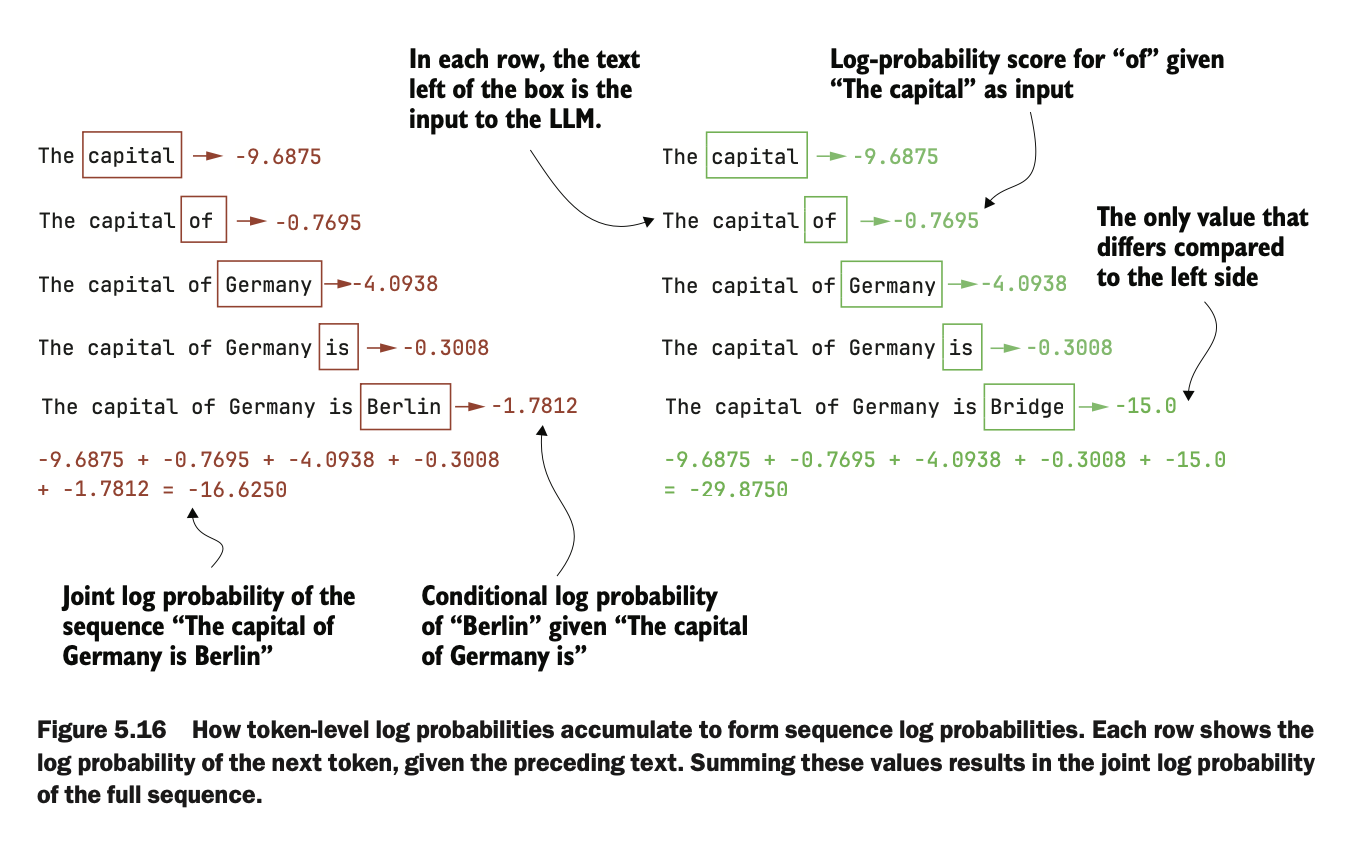
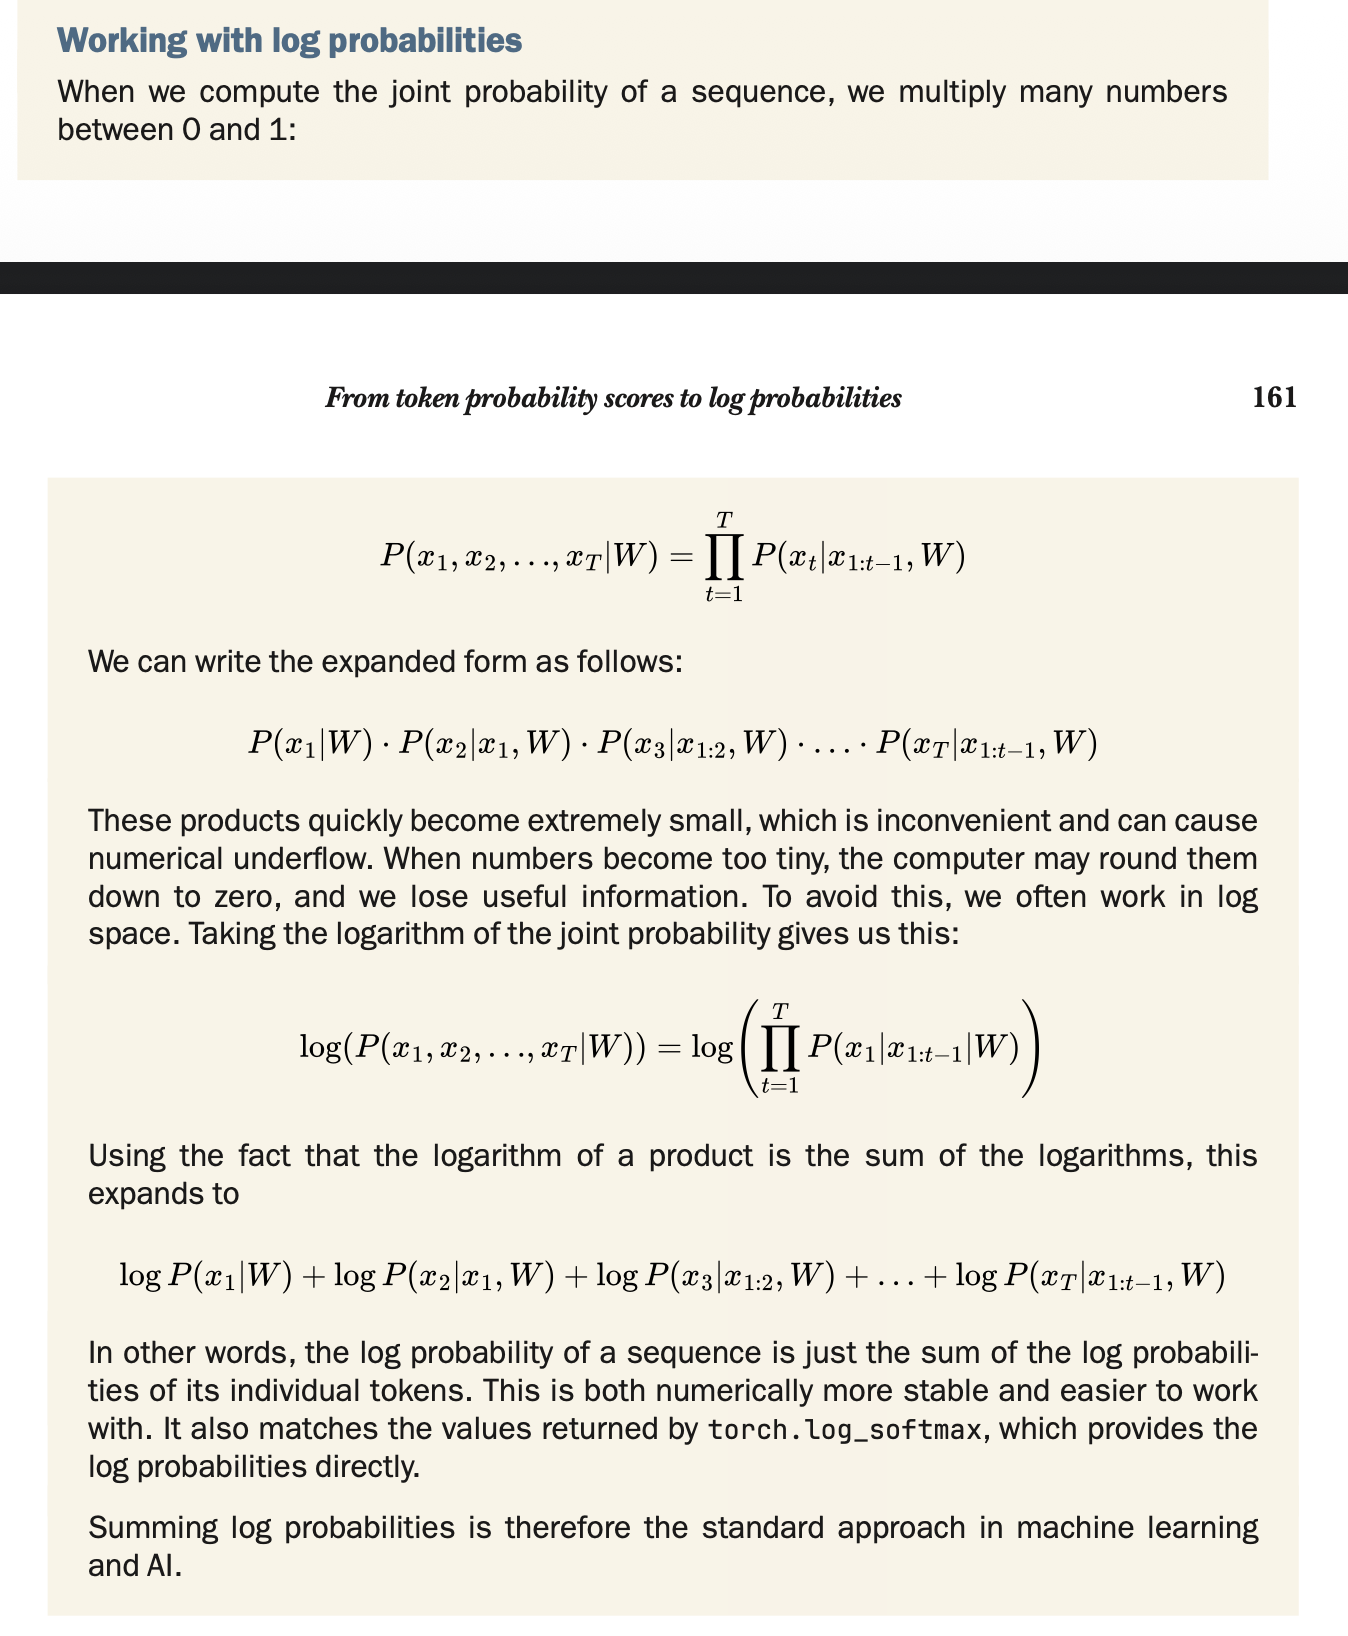


In [15]:
# Listing 5.7 Calculating next-token log probabilities


@torch.inference_mode()
def calc_next_token_logprobas(model, tokenizer, prompt, device, show=True):

    token_ids = torch.tensor(tokenizer.encode(prompt), device=device)

    logits = model(token_ids.unsqueeze(0)).squeeze(0)

    # We now use log_softmax
    all_logprobas = torch.log_softmax(logits, dim=-1)

    t_idx = torch.arange(0, token_ids.shape[0] - 1, device=device)
    next_ids = token_ids[1:]
    next_token_logprobas = all_logprobas[t_idx, next_ids]

    # We replace the product with a sum
    sum_next_token_logprobas = torch.sum(next_token_logprobas)

    if show:
        print("Next-token log-probabilities:", next_token_logprobas)
        print("Joint log-probability:", sum_next_token_logprobas)
    else:
        return next_token_logprobas, sum_next_token_logprobas

In [16]:
calc_next_token_logprobas(
    model, tokenizer, device=device, prompt="The capital of Germany is Berlin"
)

Next-token log-probabilities: tensor([-9.7500, -0.7930, -4.1250, -0.3203, -1.8203], device='mps:0',
       dtype=torch.bfloat16)
Joint log-probability: tensor(-16.7500, device='mps:0', dtype=torch.bfloat16)


In [17]:
# Now let’s try the second sequence:

calc_next_token_logprobas(
    model, tokenizer, device=device, prompt="The capital of Germany is Bridge"
)

Next-token log-probabilities: tensor([ -9.7500,  -0.7930,  -4.1250,  -0.3203, -15.0000], device='mps:0',
       dtype=torch.bfloat16)
Joint log-probability: tensor(-30., device='mps:0', dtype=torch.bfloat16)


# 5.6 Scoring model confidence with log probabilities

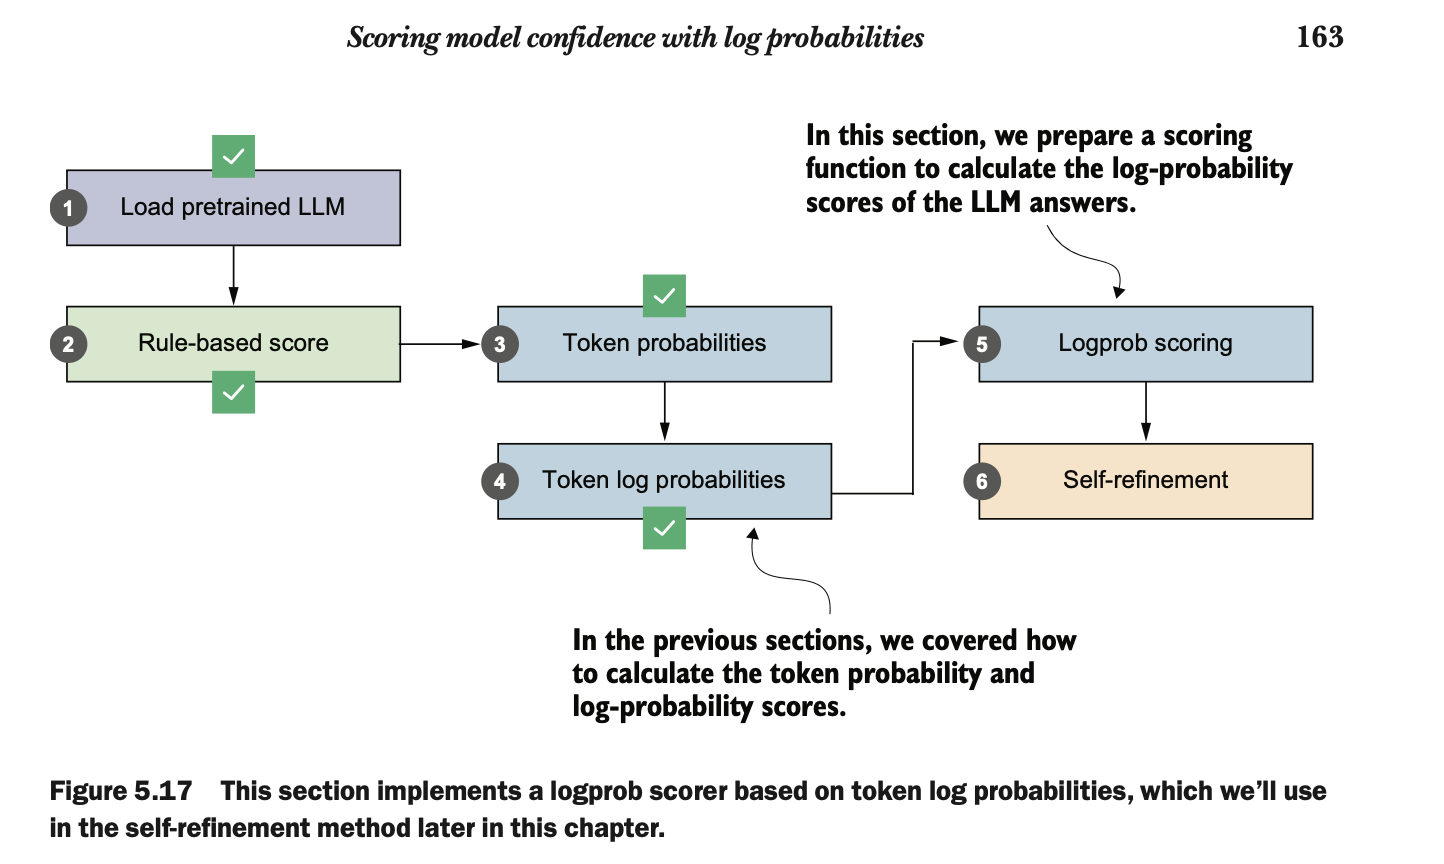


In [18]:
example_prompt = "What is the capital of Germany?"
example_answer = " The capital of Germany is Berlin."

next_token_logprobas, sum_next_token_logprobas = calc_next_token_logprobas(
    model, tokenizer, device=device, prompt=example_prompt + example_answer, show=False
)
print("Next-token logprobas:", next_token_logprobas)
print("Joint log-probability:", sum_next_token_logprobas)

Next-token logprobas: tensor([-0.4512, -0.3477, -8.2500, -0.3965, -3.7812, -2.9531, -1.2422, -0.0022,
        -0.0229, -0.0022, -0.0107, -0.0747, -0.1631], device='mps:0',
       dtype=torch.bfloat16)
Joint log-probability: tensor(-17.7500, device='mps:0', dtype=torch.bfloat16)


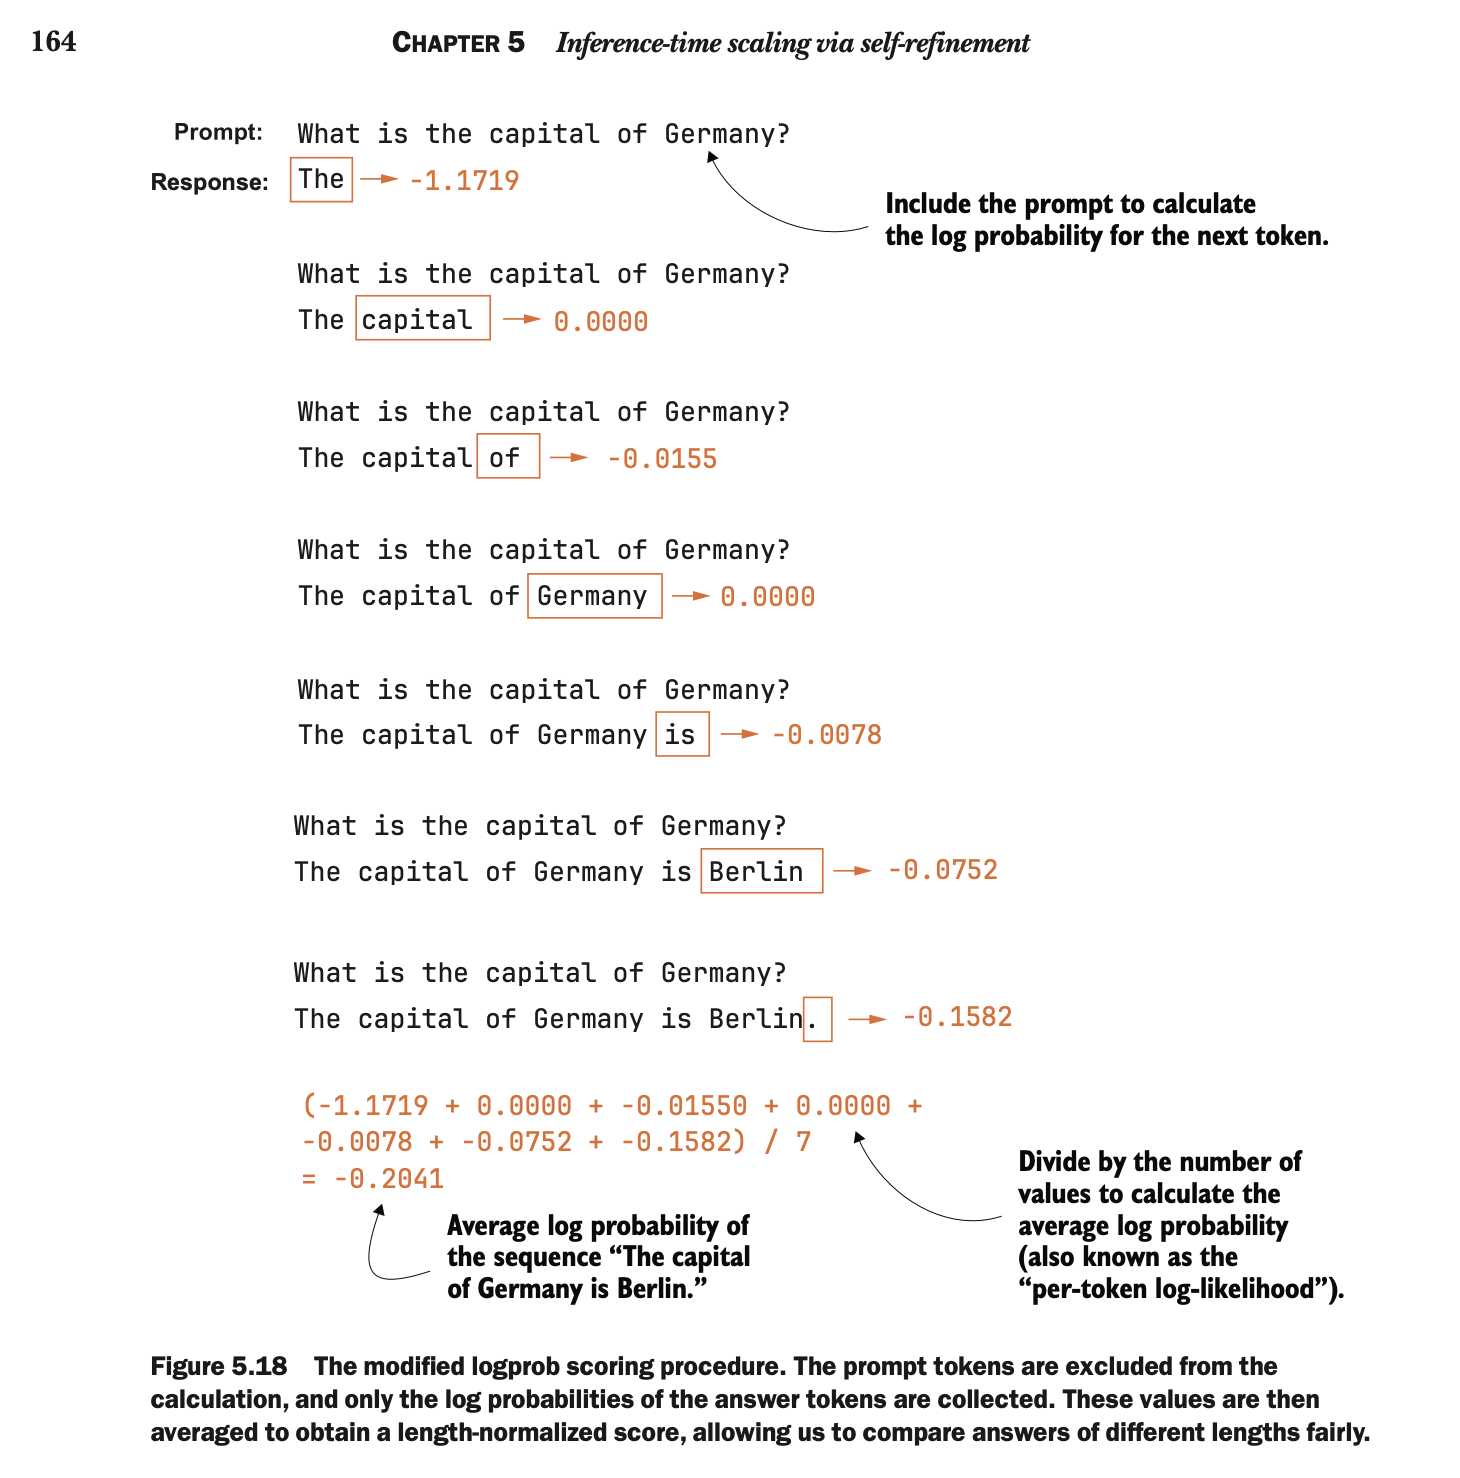


In [19]:
# We can then calculate the number of answer tokens with the following code, which
# yields 7:

print(len(tokenizer.encode(example_answer)))

7


In [20]:
# Then, to calculate the average log probability over the answer tokens, as shown in fig-
# ure 5.18, we need to average over those seven answer tokens:

last_7 = next_token_logprobas[-7:]
print(last_7)
print(torch.mean(last_7))

tensor([-1.2422, -0.0022, -0.0229, -0.0022, -0.0107, -0.0747, -0.1631],
       device='mps:0', dtype=torch.bfloat16)
tensor(-0.2168, device='mps:0', dtype=torch.bfloat16)


In [21]:
@torch.inference_mode()
def avg_logprob_answer(model, tokenizer, prompt, answer, device="cpu"):

    # Encode prompt and answer tokens separately to get the prompt length later
    prompt_ids = tokenizer.encode(prompt)
    answer_ids = tokenizer.encode(answer)
    full_ids = torch.tensor(prompt_ids + answer_ids, device=device)

    # Same as in calc_next_token_logprobas before
    logits = model(full_ids.unsqueeze(0)).squeeze(0)
    logprobs = torch.log_softmax(logits, dim=-1)

    # Index range for positions corresponding to answer tokens
    start = len(prompt_ids) - 1
    end = full_ids.shape[0] - 1

    # Same as before, except for using start and end
    t_idx = torch.arange(start, end, device=device)
    next_tokens = full_ids[start + 1 : end + 1]
    next_token_logps = logprobs[t_idx, next_tokens]

    # Average over the answer token scores
    return torch.mean(next_token_logps)

In [ ]:
score_1 = avg_logprob_answer(
    model,
    tokenizer,
    prompt="What is the capital of Germany?",
    answer=" The capital of Germany is Berlin.",
    device=device,
)
print(score_1)

tensor(-0.2168, device='mps:0', dtype=torch.bfloat16)


In [25]:
# We can now also apply this function to the nonsensical "Bridge" answer:

score_2 = avg_logprob_answer(
    model,
    tokenizer,
    prompt="What is the capital of Germany?",
    answer=" The capital of Germany is Bridge.",
    device=device,
)
print(score_2)

tensor(-3.8906, device='mps:0', dtype=torch.bfloat16)


# 5.7 Self-refinement through iterative feedback

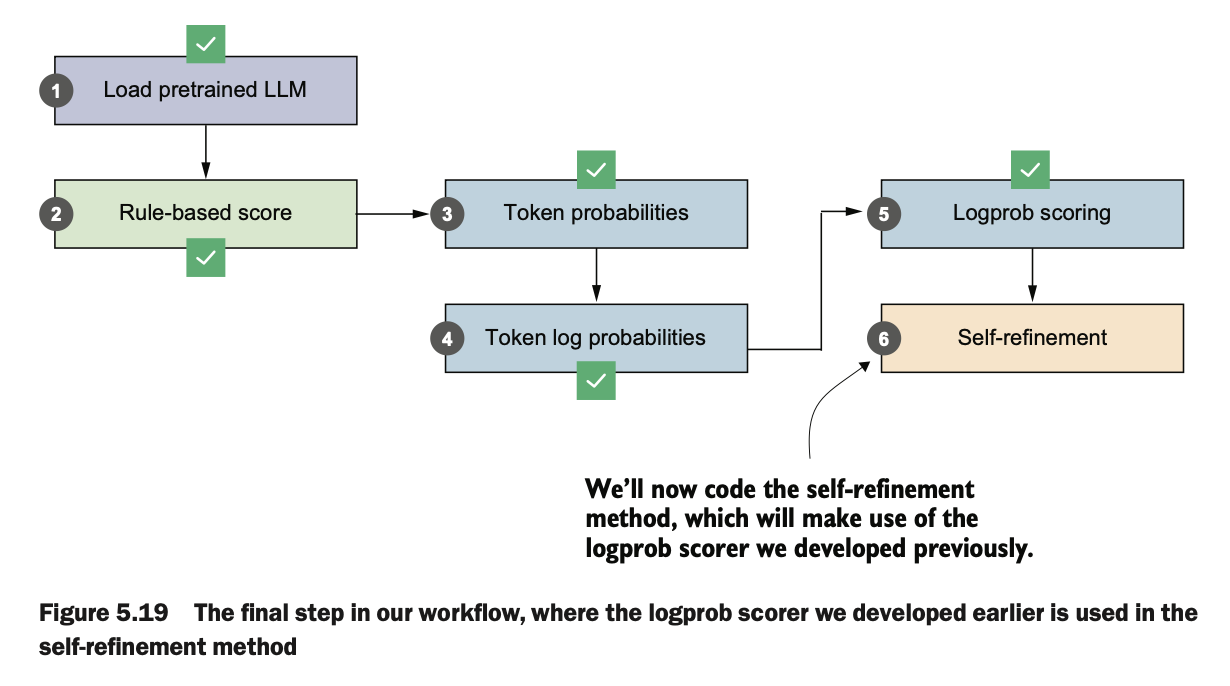
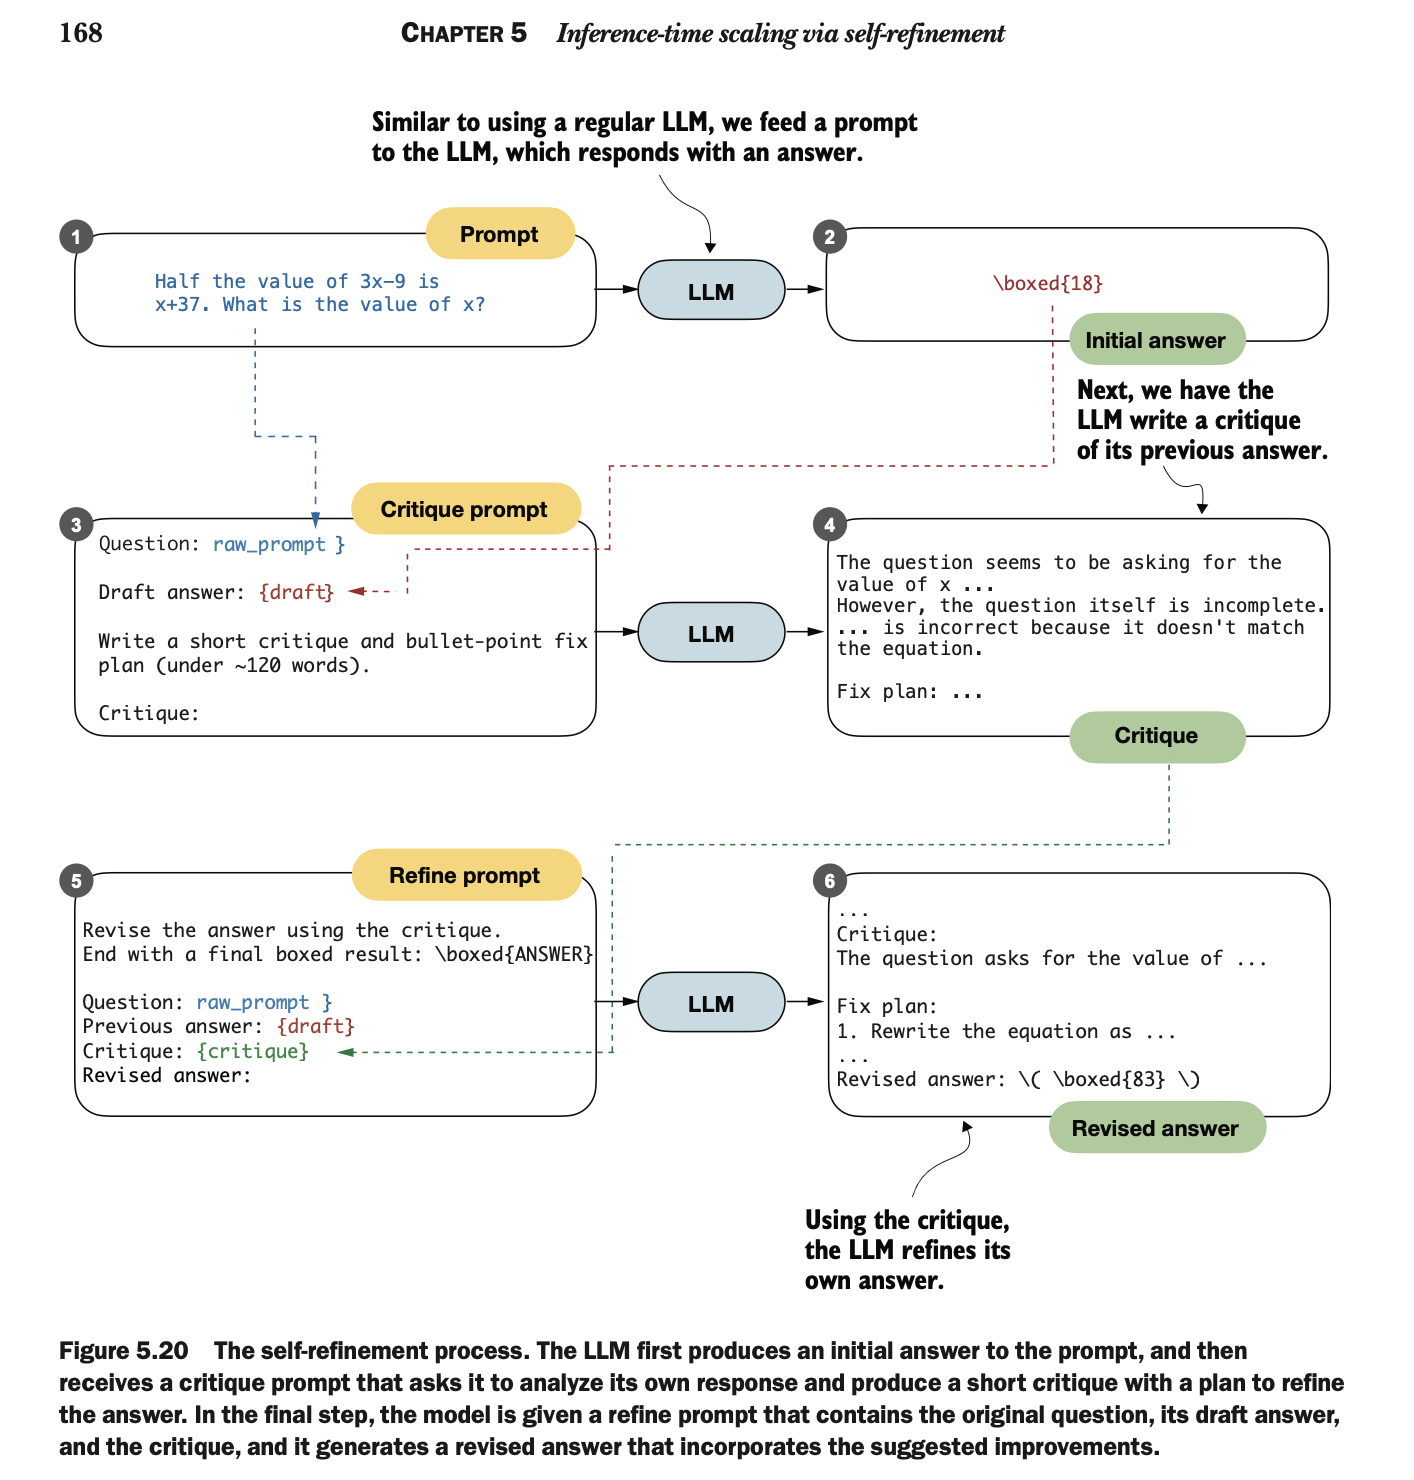


In [27]:
# Listing 5.9 Base prompt and answer

raw_prompt = "Half the value of $3x-9$ is $x+37$. " "What is the value of $x$?"
prompt = render_prompt(raw_prompt)
torch.manual_seed(123)

In [29]:
initial_response = generate_text_stream_concat_flex(
    model,
    tokenizer,
    prompt,
    device,
    max_new_tokens=2048,
    verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9,
)

 To solve the equation "Half the value of \( 3x - 9 \) is \( x + 37 \)", follow these steps:

1. **Understand the equation:**
   
   The problem states that half the value of \( 3x - 9 \) is equal to \( x + 37 \). Mathematically, this can be written as:
   \[
   \frac{1}{2} (3x - 9) = x + 37
   \]

2. **Eliminate the fraction:**
   
   Multiply both sides of the equation by 2 to eliminate the fraction:
   \[
   2 \times \frac{1}{2} (3x - 9) = 2 \times (x + 37)
   \]
   \[
   3x - 9 = 2x + 74
   \]

3. **Isolate the variable \( x \):**
   
   Subtract \( 2x \) from both sides to get all \( x \)-terms on one side:
   \[
   3x - 2x - 9 = 74
   \]
   \[
   x - 9 = 74
   \]

4. **Solve for \( x \):**
   
   Add 9 to both sides to isolate \( x \):
   \[
   x = 74 + 9
   \]
   \[
   x = 83
   \]

5. **Final Answer:**
   
   The value of \( x \) is:
   \[
   \boxed{83}
   \]

In [ ]:
# Listing 5.10 Critique prompt and refinement plan


def make_critique_prompt(raw_prompt, draft):
    return (
        "You are a meticulous reviewer. Identify logical errors, missing "
        "steps, or arithmetic mistakes. If the answer seems correct, "
        "say so briefly. Then propose a concise plan to fix issues.\n\n"
        f"Question:\n{raw_prompt}\n\n"
        f"Draft answer:\n{draft}\n\n"
        "Write a short critique and bullet-point fix plan "
        "(under ~120 words).\n"
        "Critique:"
    )


critique_prompt = make_critique_prompt(raw_prompt, initial_response)
torch.manual_seed(123)

critique = generate_text_stream_concat_flex(
    model,
    tokenizer,
    critique_prompt,
    device,
    max_new_tokens=2048,
    verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9,
)

 The solution is concise and follows a logical sequence, but there's a minor arithmetic error in the third step. The correct equation should be \( 3x - 9 = 2x + 74 \), not \( 3x - 9 = 2x + 74 \).

Fix Plan: 
1. Correct the equation by removing the "2x" from the right side.
2. Ensure the subtraction and addition steps are accurate.
3. Verify the final value of \( x \) by substituting back into the original equation.

In [31]:
# Listing 5.11 Answer refinement


def make_refine_prompt(raw_prompt, draft, critique):
    return (
        "Revise the answer using the critique. Keep it concise and "
        "end with a final boxed result: \\boxed{ANSWER}\n\n"
        f"Question:\n{raw_prompt}\n\n"
        f"Previous answer:\n{draft}\n\n"
        f"Critique:\n{critique}\n\n"
        "Revised answer:"
    )


refine_prompt = make_refine_prompt(raw_prompt, initial_response, critique)
torch.manual_seed(123)

revised_answer = generate_text_stream_concat_flex(
    model,
    tokenizer,
    refine_prompt,
    device,
    max_new_tokens=2048,
    verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9,
)

 
To solve the equation "Half the value of \( 3x - 9 \) is \( x + 37 \)", follow these steps:

1. **Understand the equation:**
   
   The problem states that half the value of \( 3x - 9 \) is equal to \( x + 37 \). Mathematically, this can be written as:
   \[
   \frac{1}{2} (3x - 9) = x + 37
   \]

2. **Eliminate the fraction:**
   
   Multiply both sides of the equation by 2 to eliminate the fraction:
   \[
   2 \times \frac{1}{2} (3x - 9) = 2 \times (x + 37)
   \]
   \[
   3x - 9 = 2x + 74
   \]

3. **Isolate the variable \( x \):**
   
   Subtract \( 2x \) from both sides to get all \( x \)-terms on one side:
   \[
   3x - 2x - 9 = 74
   \]
   \[
   x - 9 = 74
   \]

4. **Solve for \( x \):**
   
   Add 9 to both sides to isolate \( x \):
   \[
   x = 74 + 9
   \]
   \[
   x = 83
   \]

5. **Final Answer:**
   
   The value of \( x \) is:
   \[
   \boxed{83}
   \]

# 5.8 Coding the self-refinement loop

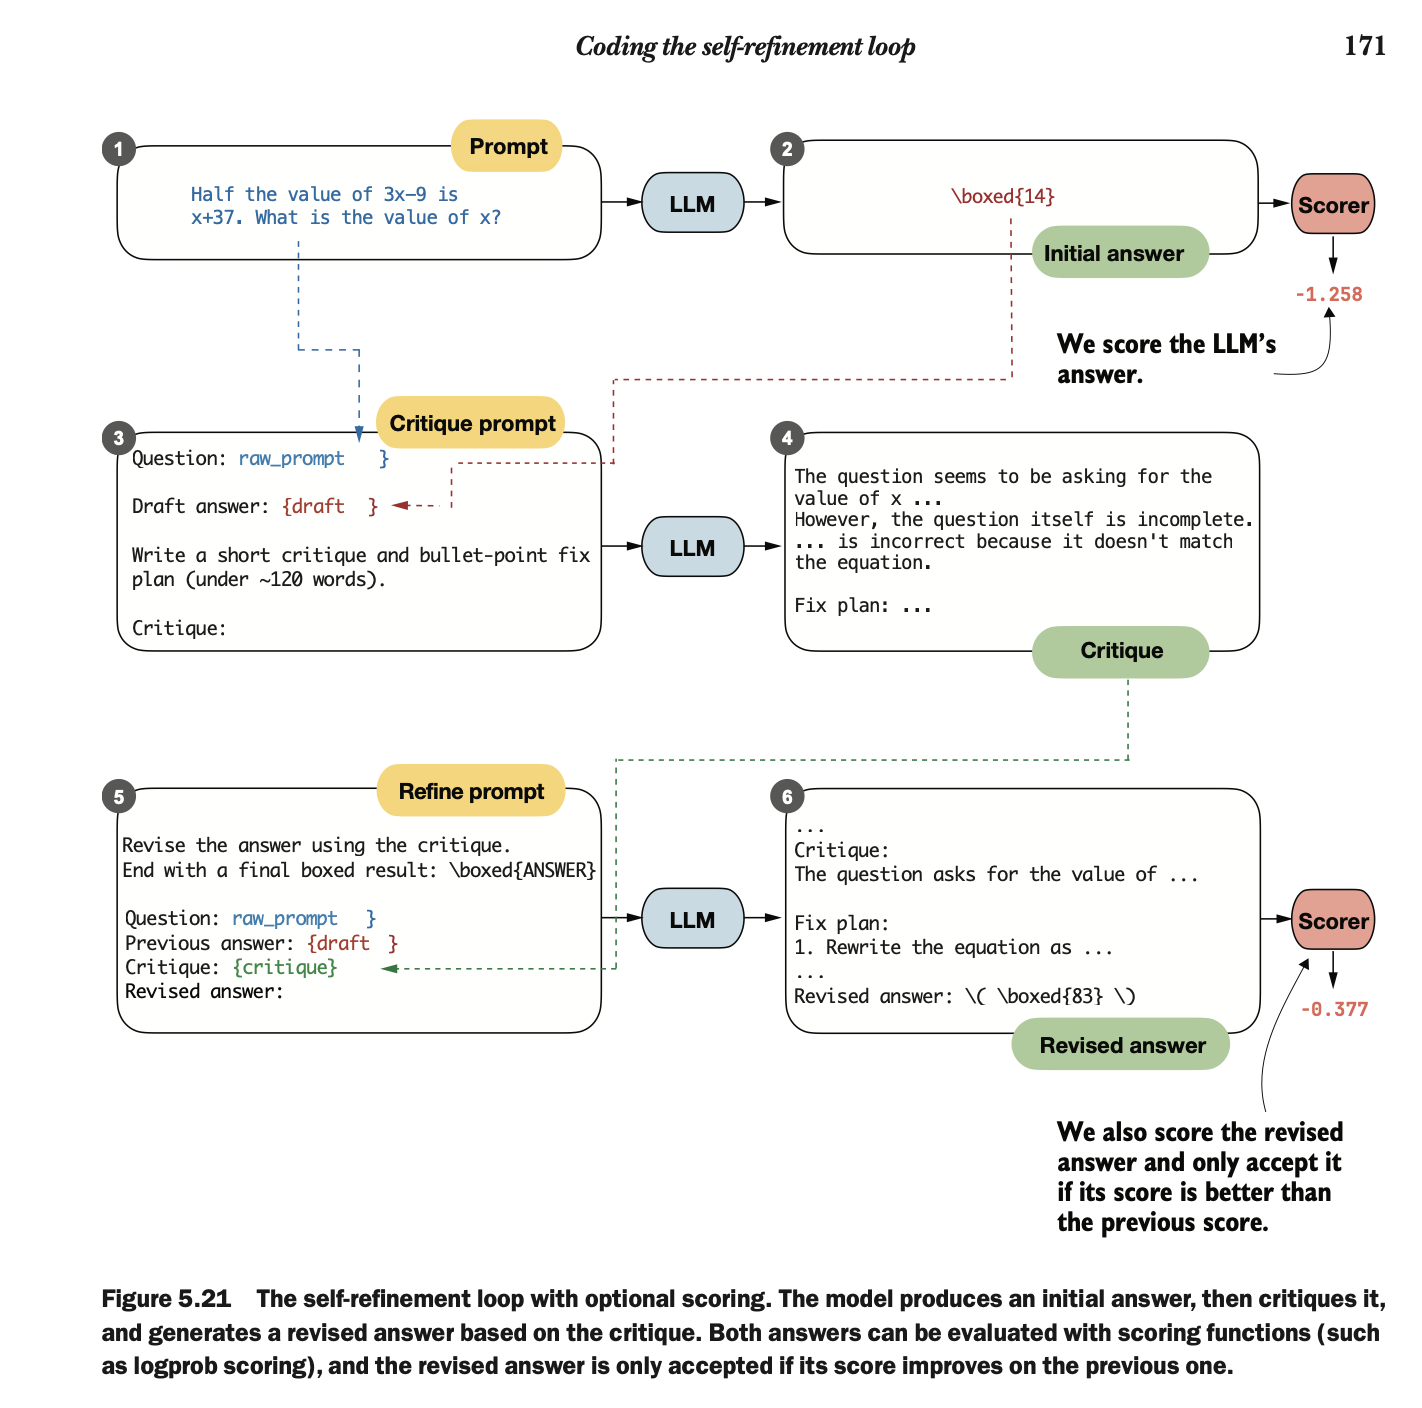


# Listing 5.12 :

## Self-refinement with multiple iterations and scoring support


In [32]:
def self_refinement_loop(
    model,
    tokenizer,
    raw_prompt,
    device,
    iterations=2,
    max_response_tokens=2048,
    max_critique_tokens=256,
    score_fn=None,
    prompt_renderer=render_prompt,
    prompt_suffix="",
    verbose=False,
    temperature=0.7,
    top_p=0.9,
):
    steps = []

    # Initial response (draft)
    prompt = prompt_renderer(raw_prompt) + prompt_suffix
    current_full = generate_text_stream_concat_flex(
        model=model,
        tokenizer=tokenizer,
        prompt=prompt,
        device=device,
        max_new_tokens=max_response_tokens,
        verbose=False,
        generate_func=generate_text_top_p_stream_cache,
        temperature=temperature,
        top_p=top_p,
    )

    current_extracted = extract_final_candidate(
        current_full, fallback="number_then_full"
    )
    if score_fn:
        current_score = score_fn(answer=current_full, prompt=prompt)
    else:
        current_score = 0.0

    # Run for one or more iterations
    for it in range(iterations):
        draft_before_full = current_full
        draft_before_extracted = current_extracted
        score_before = current_score

        # Critique the response
        critique_prompt = make_critique_prompt(raw_prompt, draft_before_full)
        critique_full = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=critique_prompt,
            device=device,
            max_new_tokens=max_critique_tokens,
            verbose=False,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature,
            top_p=top_p,
        )

        # Refine the response
        refine_prompt = make_refine_prompt(raw_prompt, draft_before_full, critique_full)
        revised_full = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=refine_prompt,
            device=device,
            max_new_tokens=max_response_tokens,
            verbose=False,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature,
            top_p=top_p,
        )

        revised_extracted = extract_final_candidate(
            revised_full, fallback="number_then_full"
        )
        if score_fn:
            revised_score = score_fn(
                answer=revised_full, prompt=prompt  # Still use original prompt here
            )
        else:
            revised_score = 0.0

        # Log the results
        step = {
            "iteration": it + 1,
            "draft_full": draft_before_full,
            "draft_extracted": draft_before_extracted,
            "critique": critique_full,
            "revised_full": revised_full,
            "revised_extracted": revised_extracted,
            "score_before": score_before,
            "score_after": revised_score,
        }
        steps.append(step)

        if verbose:
            print(
                f"[Refinement {it+1}/{iterations}]"
                f"\nCurrent: {draft_before_extracted}"
                f"\nRevised: {revised_extracted}"
                f"\nScore before: {score_before:.3f}"
                f"\nScore after: {revised_score:.3f}"
                f"\n{'=' * 25}"
            )

        # Accept revised response if it's not worse
        if revised_score >= current_score:
            current_full = revised_full
            current_extracted = revised_extracted
            current_score = revised_score

    return {
        "final_full": current_full,
        "final_extracted": current_extracted,
        "steps": steps,
    }

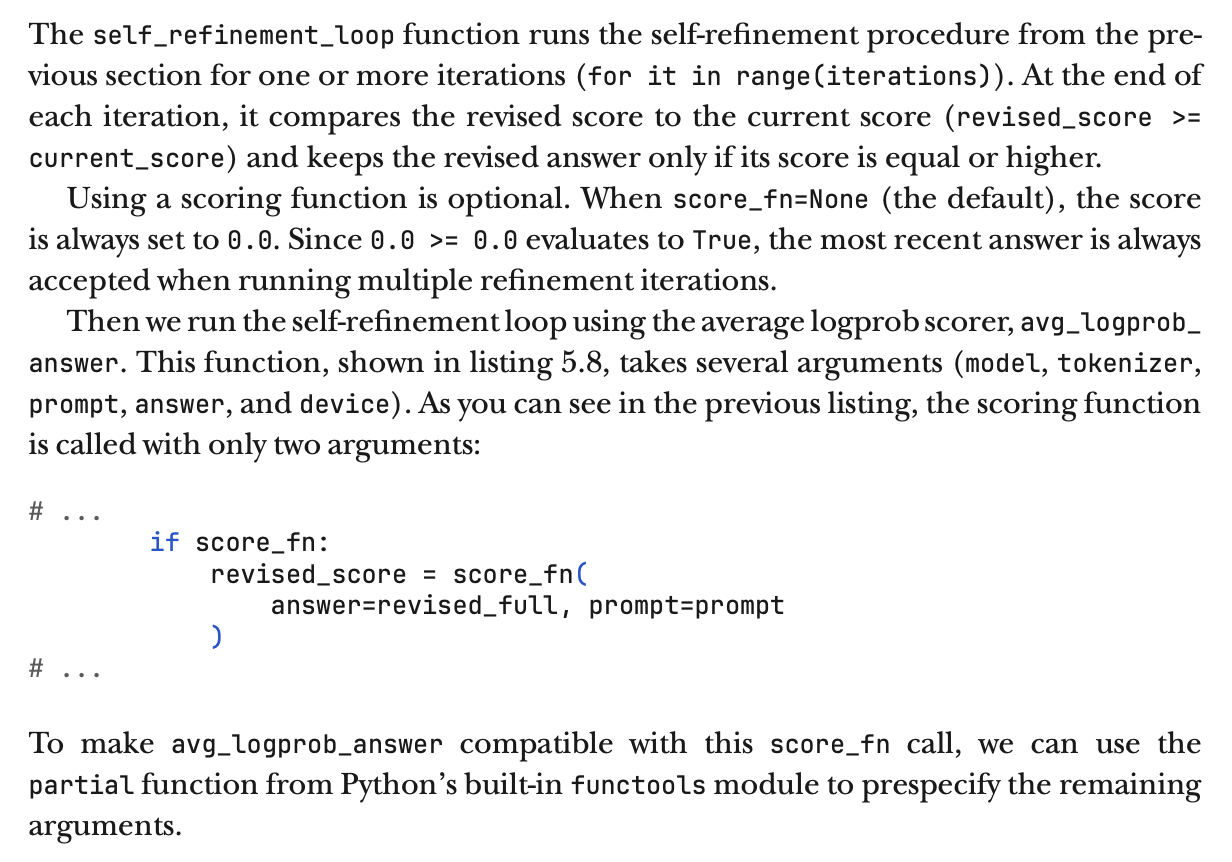


In [34]:
# Listing 5.13 Creating an average log-probability scorer

from functools import partial

avg_logprob_score = partial(
    avg_logprob_answer, model=model, tokenizer=tokenizer, device=device
)

In [35]:
# Now we can use the avg_logprob_score function in the self-refinement loop:

torch.manual_seed(1)

results_logprob = self_refinement_loop(
    model=model,
    tokenizer=tokenizer,
    raw_prompt=raw_prompt,
    device=device,
    iterations=2,
    max_response_tokens=2048,
    max_critique_tokens=256,
    score_fn=avg_logprob_score,
    verbose=True,
    temperature=0.7,
    top_p=0.9,
)

[Refinement 1/2]
Current: 83
Revised: 83
Score before: -0.087
Score after: -0.086
[Refinement 2/2]
Current: 83
Revised: 83
Score before: -0.086
Score after: -0.703


In [ ]:
# Acces final answer extracted from the best-scoring response:
results_logprob["final_extracted"]

'83'

In [46]:
# Acces full response
results_logprob["final_full"]

' \n\nTo solve for \\( x \\), we start with the equation given in the problem:\n\n\\[\n\\frac{1}{2} \\times (3x - 9) = x + 37\n\\]\n\n**Step 1: Eliminate the fraction by multiplying both sides by 2.**\n\n\\[\n2 \\times \\left( \\frac{1}{2} \\times (3x - 9) \\right) = 2 \\times (x + 37)\n\\]\n\nSimplifying both sides:\n\n\\[\n3x - 9 = 2x + 74\n\\]\n\n**Step 2: Subtract \\( 2x \\) from both sides to gather like terms.**\n\n\\[\n3x - 2x - 9 = 74\n\\]\n\n\\[\nx - 9 = 74\n\\]\n\n**Step 3: Add 9 to both sides to solve for \\( x \\).**\n\n\\[\nx = 74 + 9\n\\]\n\n\\[\nx = 83\n\\]\n\n**Final Answer:**\n\n\\[\n\\boxed{83}\n\\]\n\nCritique:\n The solution is correct but the steps are not fully detailed, which may confuse some readers.\n\nFix Plan: \n1. Add a brief explanation for each step.\n2. Use consistent notation throughout the solution.\n3. Include a check for any arithmetic mistakes.\n\nRevised answer: \n\nTo solve for \\( x \\), we start with the equation given in the problem:\n\n\\[\n\\f

In [47]:
# To read through the critiques and longer answers, you
# can print the results_logprob dictionary, which contains the detailed results for all
# iterations.

print(results_logprob)

{'final_full': ' \n\nTo solve for \\( x \\), we start with the equation given in the problem:\n\n\\[\n\\frac{1}{2} \\times (3x - 9) = x + 37\n\\]\n\n**Step 1: Eliminate the fraction by multiplying both sides by 2.**\n\n\\[\n2 \\times \\left( \\frac{1}{2} \\times (3x - 9) \\right) = 2 \\times (x + 37)\n\\]\n\nSimplifying both sides:\n\n\\[\n3x - 9 = 2x + 74\n\\]\n\n**Step 2: Subtract \\( 2x \\) from both sides to gather like terms.**\n\n\\[\n3x - 2x - 9 = 74\n\\]\n\n\\[\nx - 9 = 74\n\\]\n\n**Step 3: Add 9 to both sides to solve for \\( x \\).**\n\n\\[\nx = 74 + 9\n\\]\n\n\\[\nx = 83\n\\]\n\n**Final Answer:**\n\n\\[\n\\boxed{83}\n\\]\n\nCritique:\n The solution is correct but the steps are not fully detailed, which may confuse some readers.\n\nFix Plan: \n1. Add a brief explanation for each step.\n2. Use consistent notation throughout the solution.\n3. Include a check for any arithmetic mistakes.\n\nRevised answer: \n\nTo solve for \\( x \\), we start with the equation given in the probl

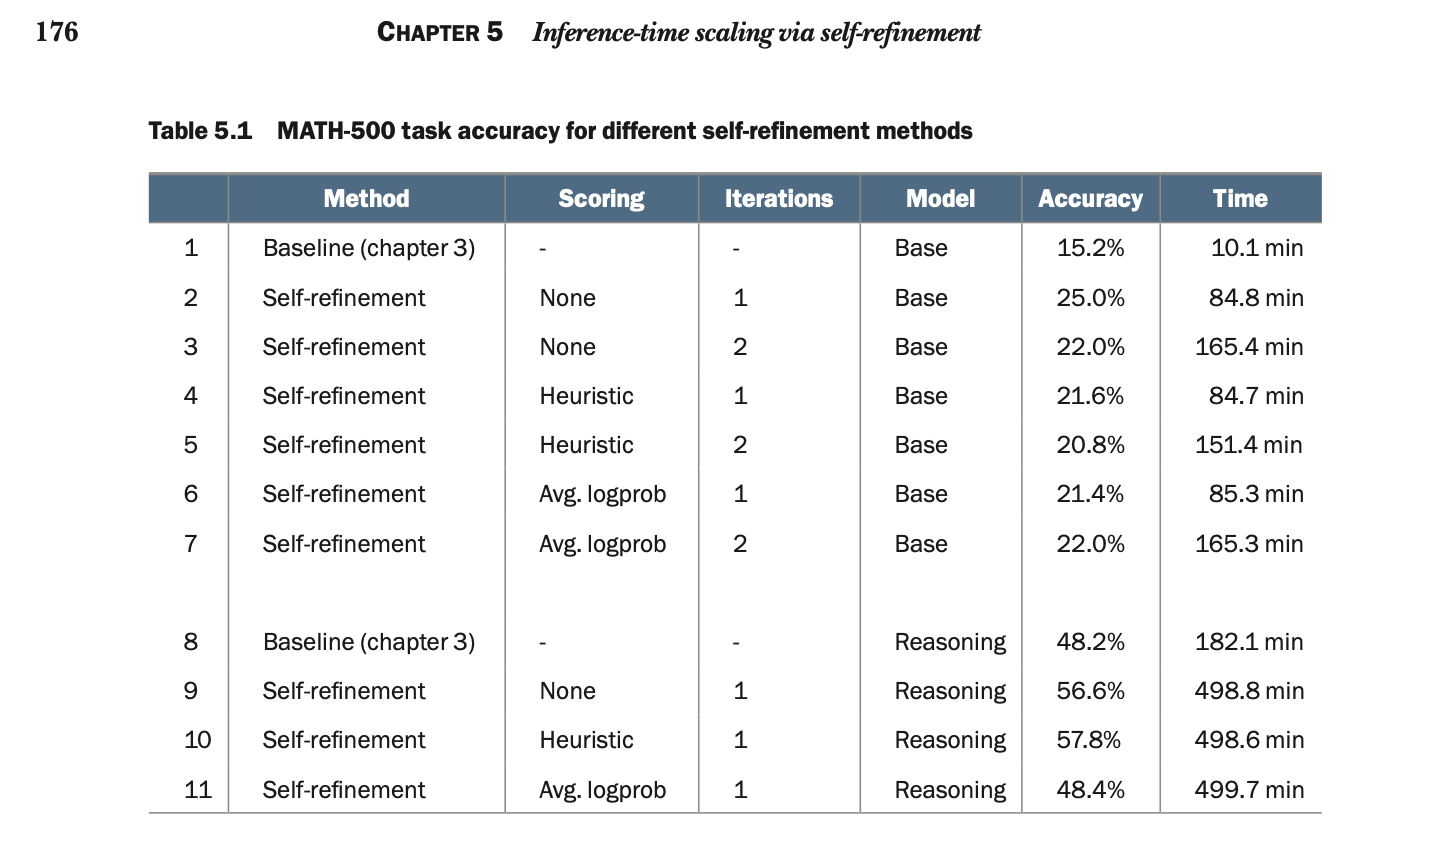


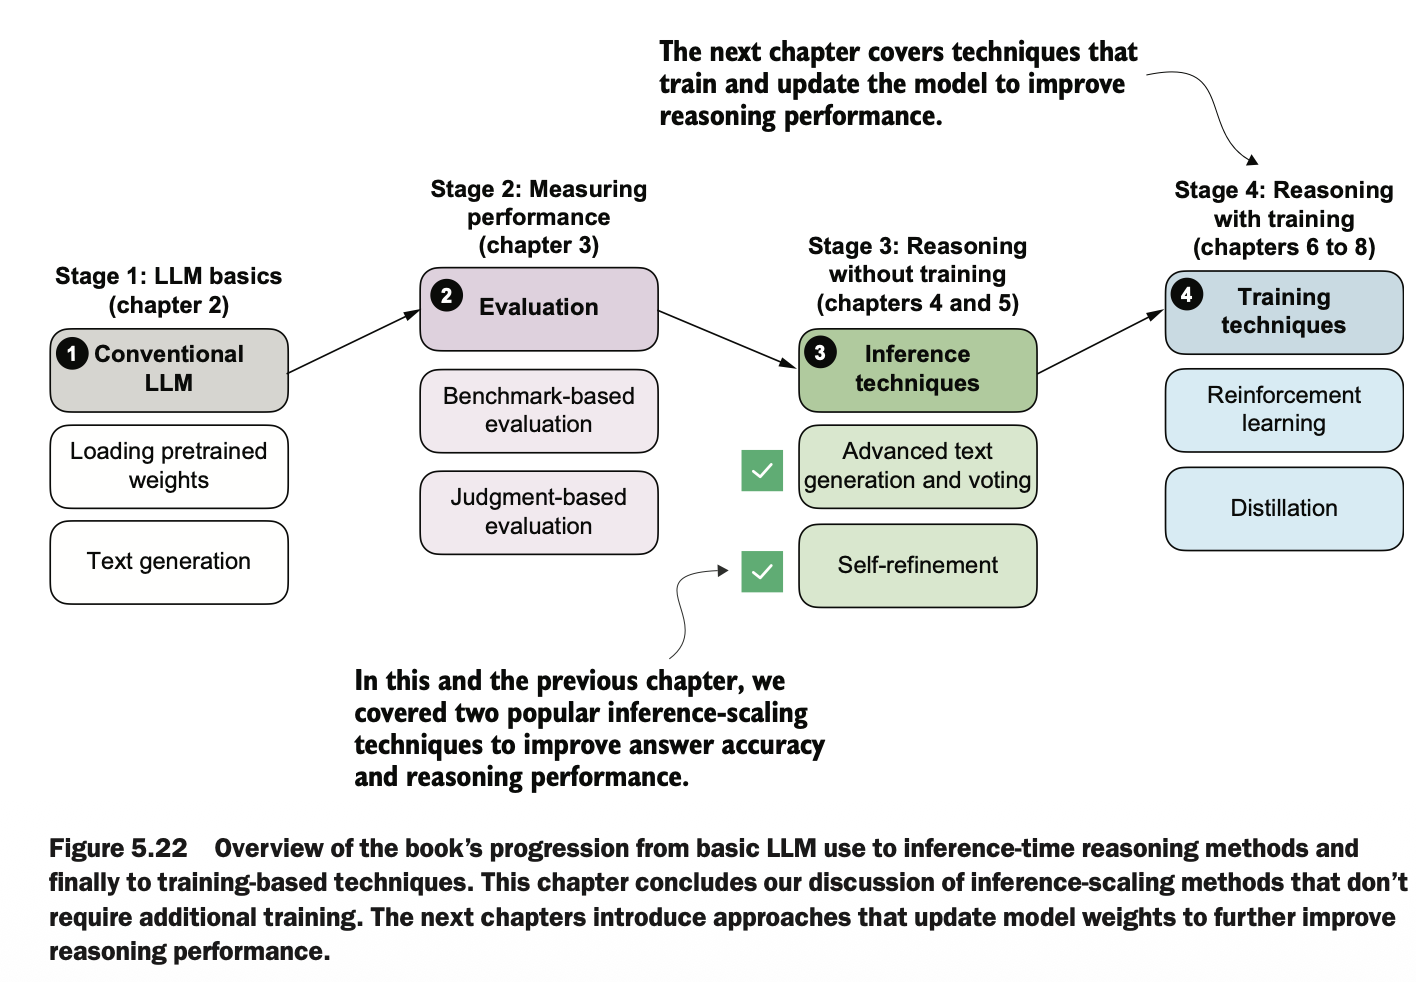
